# Searching for a chord progression: three pitch hypotheses

**Our task:** look for an independently specified D-major → A-major → D-major
triad sequence, allowing uniform changes of tempo. How does the answer change
when we require its exact pitches, ignore octaves, or move its voicing through
the score's entire pitch range?

We choose the progression **before examining the note table**. The query is
written below, not cropped from the score. A complete match is not guaranteed:
the strongest **near hits** can suggest which chord, voicing or duration to
investigate next.

We compare three cases throughout:

1. **MIDI fixed:** the specified absolute pitches and voicing, sliding in time.
2. **Chroma:** the specified pitch classes at any octave, sliding in time.
3. **MIDI moving:** the same interval pattern and voicing, sliding across every
   valid pitch **and** time position. A single semitone shift applies to all notes. For this template the relative
   chord relationship is **I–V–I (tonic–dominant–tonic, T–D–T)**, in different
   candidate keys: a −2 shift requests C–G–C, not D–A–D.

Follow **parse → build MIDI/chroma grids → define a query → choose time scales
→ run all three searches → compare tables and heatmaps → show every shortlisted
hit in the piano roll and original notation → inspect missing requirements →
refine the musical question**.

The [pattern-search compendium](binary_pattern_search.ipynb) explains scoring,
pitch augmentation, voices and filtering; [the roundtrip notebook](binary_roundtrip.ipynb)
explains representation loss. Rhythmic-pattern search is a separate future study.


In [1]:
try:
    import camat
except ModuleNotFoundError:
    import setup_camat
    import camat

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from html import escape
from matplotlib.colors import to_hex
from camat import find_camat_root, parse_files, resolve_mei_source, midi_to_name
from camat.music_utils import create_binary_matrix_bundle, draw_piano_roll
from camat.binary_roundtrip import (
    prepare_binary_timeline, plot_binary_comparison, binary_match_sources, plot_matched_source, plot_matched_sources,
)
from camat.binary_query import (
    search_binary_query, rank_query_matches, plot_query_heatmaps,
    plot_binary_query_match, plot_query_loss_examples,
)
from camat.verovio_render import vrv_load_from_file, vrv_quiet, vrv_set_options, vrv_render_source_context
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


## 1. Parse the source and retain its musical context

We use Bach's *Ein feste Burg* from the shared cache. If it is unavailable,
CAMAT uses its bundled example so this notebook still runs offline. The printed
source path identifies which score was actually searched. Set `RUN_FETCH=True`
to fetch Bach, or set `MEI_SOURCE` to a local MEI file.

Keep note IDs, voices, durations and measure boundaries. A pickup can have
negative source onsets, so we shift notes and barlines together onto a zero-based
grid. Later results report both original source time and grid time.


Processing (verovio): e871590b3deb571b.mei -> 00_e871590b3deb571b
Dropped weaker duplicate MEI text events: 10 row(s) without usable anchors.
Extracted non-barline MEI events: 99 event(s), types=['fermata', 'lyric', 'measure', 'slur', 'tie'].
Searched source: /home/egor/.cache/camat/downloads/e871590b3deb571b.mei
235 notes; grid time 0 = source -1 QL


,xml_id,Voice,MIDI,Global Onset,Source Global Onset,Duration
0,d1e93,P2 - Voice 2,62,0.0,-1.0,0.5
1,d1e92,P2 - Voice 1,66,0.0,-1.0,1.0
2,d1e91,P1 - Voice 2,69,0.0,-1.0,1.0
3,d1e64,P1 - Voice 1,74,0.0,-1.0,1.0
4,d1e94,P2 - Voice 2,61,0.5,-0.5,0.5
5,d1e59,P2 - Voice 2,59,1.0,0.0,1.0
6,d1e487,P1 - Voice 2,62,1.0,0.0,1.0
7,d1e54,P2 - Voice 1,66,1.0,0.0,1.0


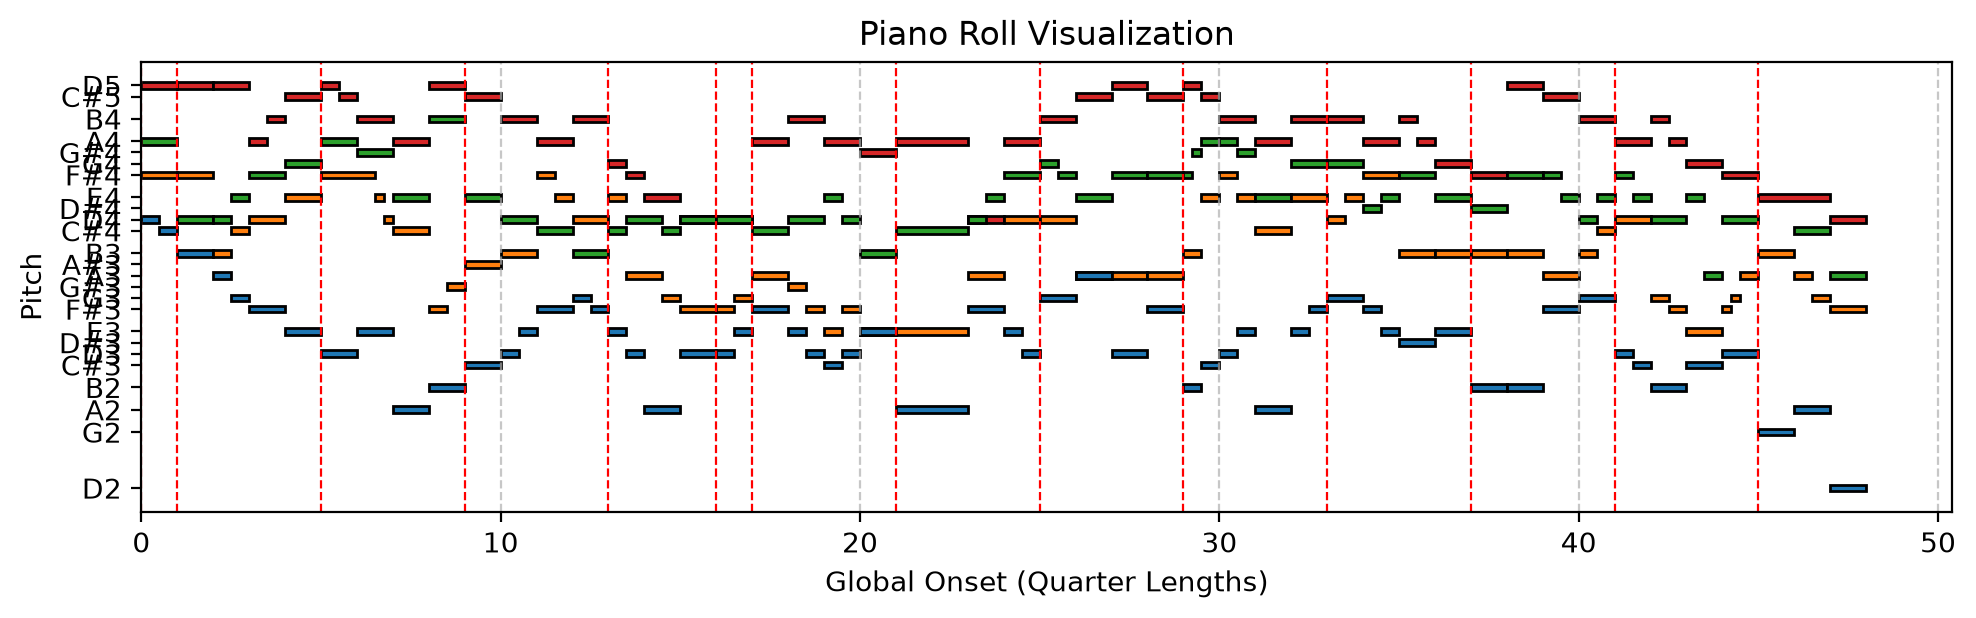

In [2]:
ROOT = find_camat_root()
BACH_SAMPLE_URL = (
    "https://raw.githubusercontent.com/music-encoding/sample-encodings/"
    "main/MEI_5.0/Music/Complete_examples/Bach-JS_Ein_feste_Burg.mei"
)
MEI_SOURCE = BACH_SAMPLE_URL
RUN_FETCH = False
PLOTTING_BACKEND = "plt"  # "plt" | "bokeh"
mei_path = resolve_mei_source(MEI_SOURCE, fetch=RUN_FETCH, shared_cache=True, repo_root=ROOT)
if mei_path is None:
    mei_path = ROOT / "camat" / "examples" / "facsimile_viewer_demo.mei"
    print("Bach is not cached: using the bundled teaching score.")
results, _, _ = parse_files(
    [str(mei_path)], backend="none", display_preview_df_pitch=False,
    display_preview_df_events=False, include_xml_ids=True, parse_enharmonic=True,
    quiet_native_warnings=True, use_remote_cache=True,
)
source_notes = results[0]["df_pitch"]
source_notes = source_notes[source_notes["Duration"] > 0].copy()
notes, measure_offsets, source_origin = prepare_binary_timeline(source_notes, results[0].get("measure_offsets"))
print(f"Searched source: {mei_path}")
print(f"{len(notes)} notes; grid time 0 = source {source_origin:g} QL")
display(notes[["xml_id", "Voice", "MIDI", "Global Onset", "Source Global Onset", "Duration"]].head(8))
draw_piano_roll(notes, measure_offsets=measure_offsets, backend=PLOTTING_BACKEND,
                show_measure_lines=True, colorize_voices=True, show_hover=True,
                plot_width=1000, plot_height=320)


## 2. Build two grids for three search cases

Both MIDI searches use **the same matrix and the same kernel**. They differ only
in allowed placements. Chroma folds all sounding MIDI notes into twelve pitch
classes, losing register, octave doubling and voice identity in the grid; source
provenance still retains the original notes.

`Y_MODE="minmax"` retains every semitone row between the score's lowest and
highest pitch, including silent rows. The moving case scans this **entire
matrix**, not a chosen pitch band. Set `Y_MODE="full"` to search all 128 MIDI
rows, including silent margins outside the score's observed register. All
placements must fit completely within whichever matrix you choose.

Both grids use the same time resolution and pickup-aware origin. Higher pitches
appear higher in the plots regardless of raw row storage order.


MIDI: (37, 192); resolution=0.25 QL
chroma: (12, 192); resolution=0.25 QL


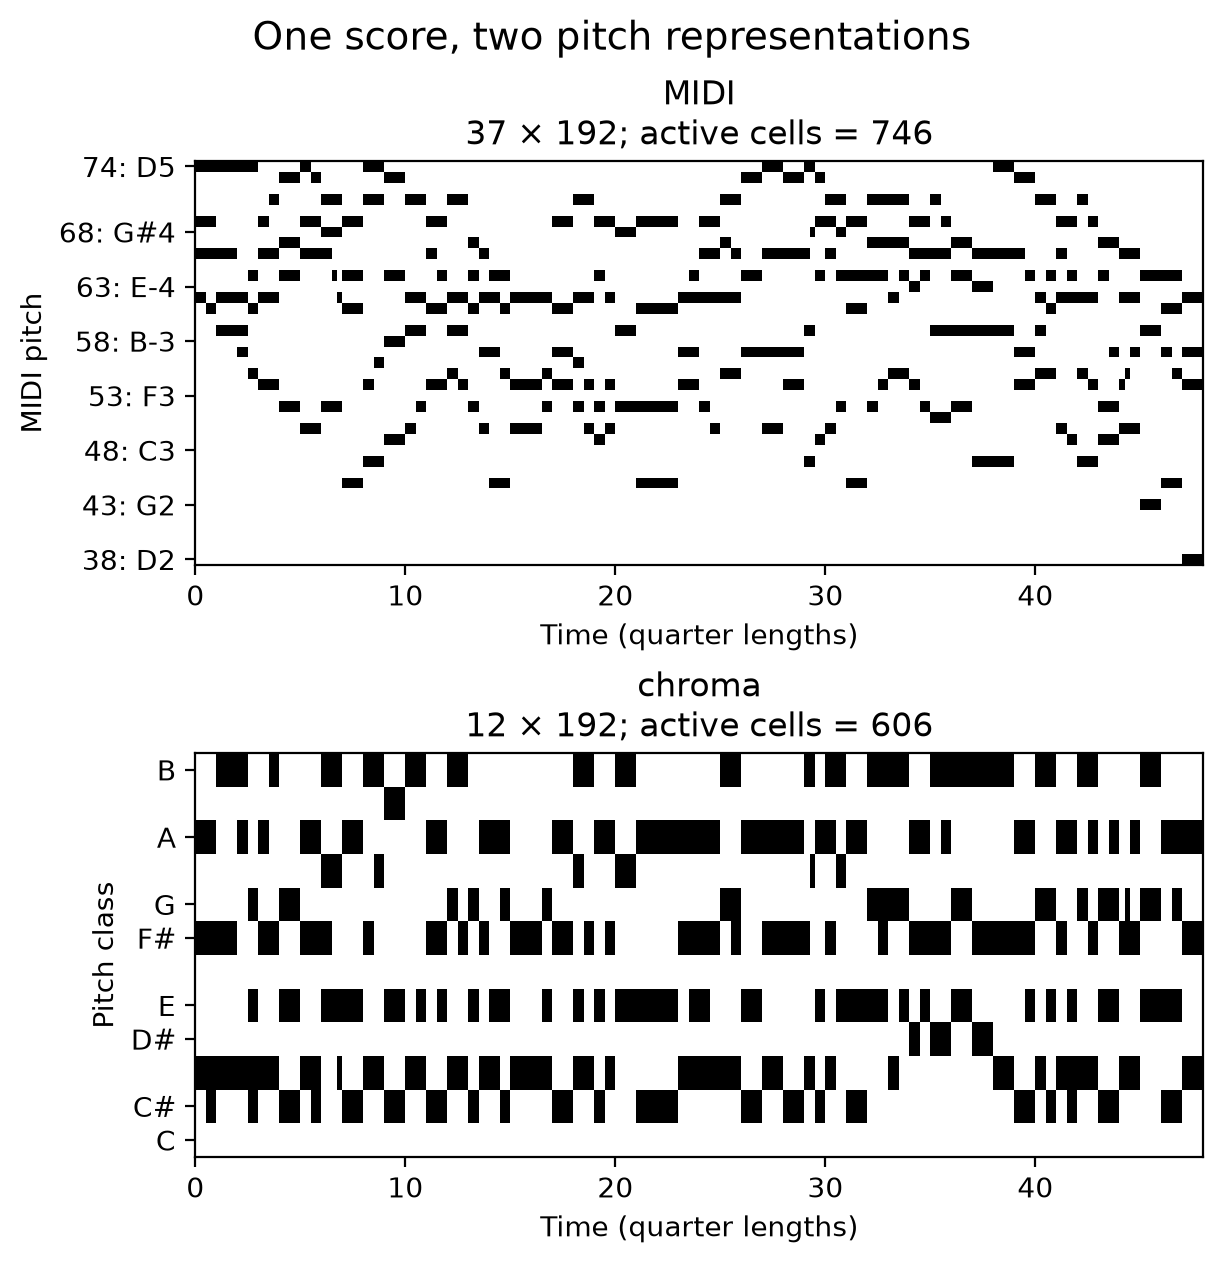

,representation,transpositions,question
case,,,
MIDI fixed,MIDI,[0],Exact absolute pitches and voicing
chroma,chroma,[0],"Original pitch classes, any octave/voicing"
MIDI moving,MIDI,all,Same voicing at every valid uniform pitch shift


In [3]:
RESOLUTION = 0.25
ROW_ORDER = "high_to_low"
Y_MODE = "minmax"  # MIDI: "minmax" | "full"; the other representation is always chroma
if Y_MODE not in {"minmax", "full"}:
    raise ValueError("Choose minmax or full for the MIDI host.")
hosts = {}
for label, mode in [("MIDI", Y_MODE), ("chroma", "chroma")]:
    hosts[label] = create_binary_matrix_bundle(
        notes, source_name=f"{mei_path.stem}: {label}", measure_offsets=measure_offsets,
        resolution_method="manual", manual_resolution=RESOLUTION,
        y_mode=mode, row_order=ROW_ORDER, include_provenance=True,
    )
    hosts[label].meta["source_time_origin"] = source_origin
    print(f"{label}: {hosts[label].matrix.shape}; resolution={RESOLUTION:g} QL")
plot_binary_comparison(hosts, ncols=1, title="One score, two pitch representations")
plt.show()

case_specs = {
    "MIDI fixed": {"representation": "MIDI", "transpositions": [0],
                   "question": "Exact absolute pitches and voicing"},
    "chroma": {"representation": "chroma", "transpositions": [0],
               "question": "Original pitch classes, any octave/voicing"},
    "MIDI moving": {"representation": "MIDI", "transpositions": "all",
                    "question": "Same voicing at every valid uniform pitch shift"},
}
case_hosts = {case: hosts[spec["representation"]] for case, spec in case_specs.items()}
display(pd.DataFrame(case_specs).T.rename_axis("case"))


## 3. Write the query ourselves

The query below asks for these simultaneous pitch sets, in this order, each for
one QL: **D4–F♯4–A4 → A3–C♯4–E4 → D4–F♯4–A4**. This MIDI voicing is a deliberate
starting hypothesis. The chroma version asks for **D–F♯–A → A–C♯–E → D–F♯–A**
at any octave, including inversions and widely spaced voicings.

No source note table is used to construct these requirements. Change `CHORDS`
or `CHORD_DURATIONS_QL` to pose another question. The matrix columns still have
the host's time resolution. Each chord's pitch classes must sound together for
the specified span; an arpeggio is not equivalent to a held triad under this query.

For this tutorial, write each chord's **root first** in its pitch list; remaining
tones may occupy any octave. We retain that declared root as query metadata so
moving-MIDI results can show their transposed chord labels. These labels describe
the **placed query requirements**, not automatic chord labels for the source.


,chord,root_pc,notes,start_QL,end_QL
stage,,,,,
1,D major,2,"D4, F#4, A4",0.0,1.0
2,A major,9,"A3, C#4, E4",1.0,2.0
3,D major,2,"D4, F#4, A4",2.0,3.0


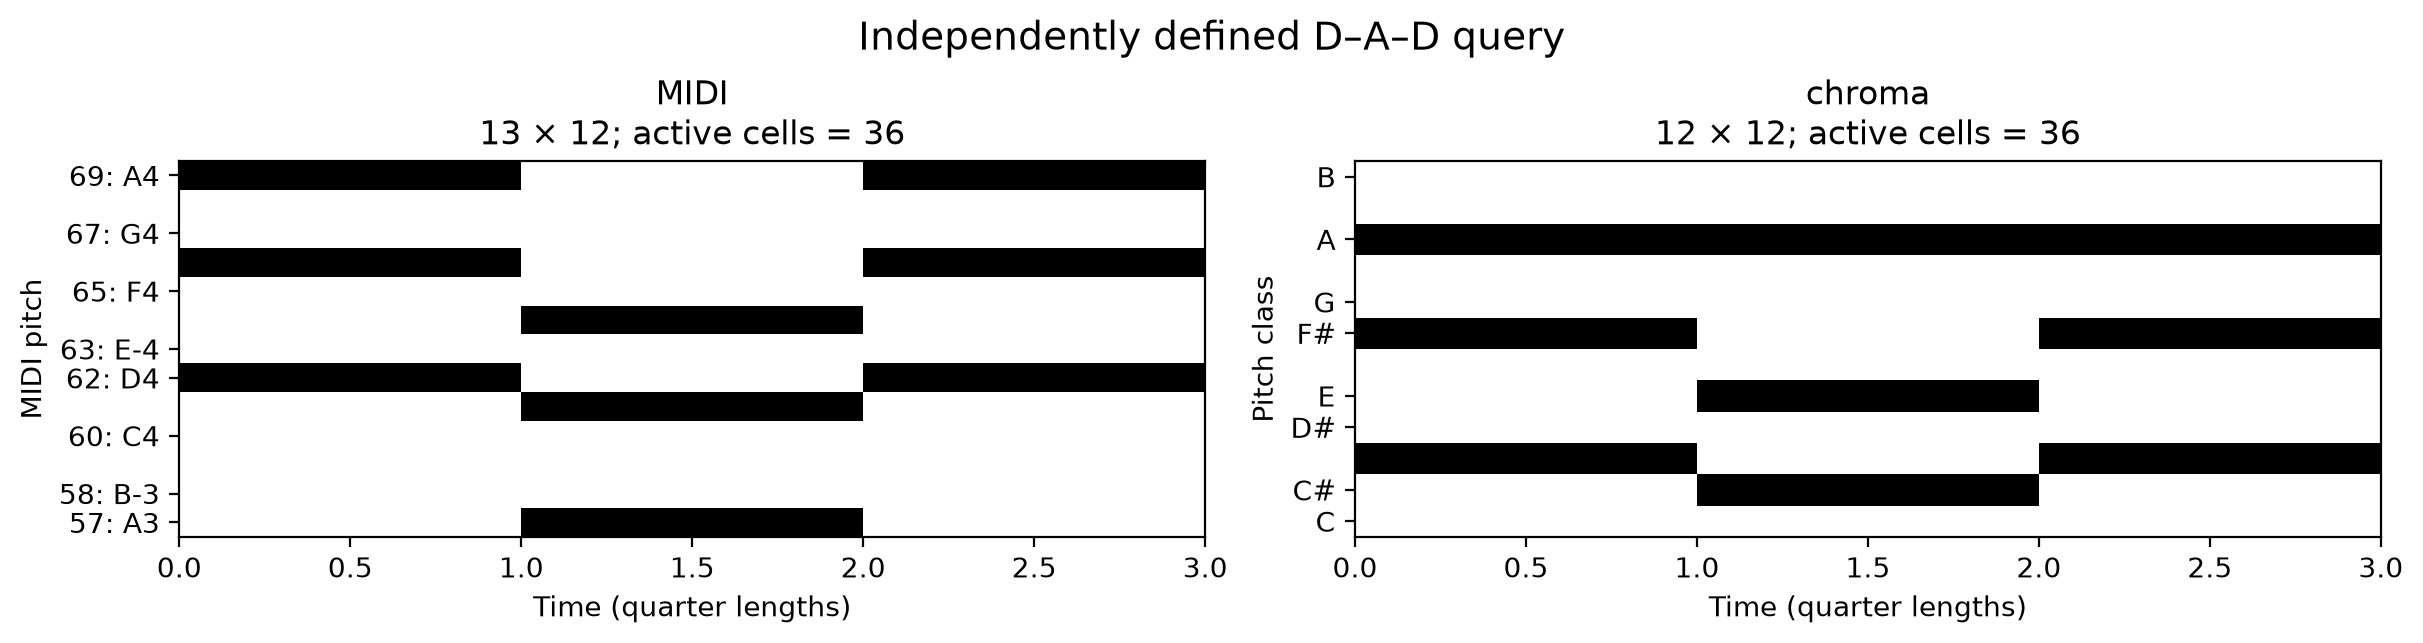

Moving query at −2 semitones: C major → G major → C major


In [4]:
CHORDS = [("D major", [62, 66, 69]), ("A major", [57, 61, 64]), ("D major", [62, 66, 69])]
CHORD_DURATIONS_QL = [1.0, 1.0, 1.0]
if len(CHORDS) != len(CHORD_DURATIONS_QL) or not CHORDS:
    raise ValueError("Provide one positive duration for each chord.")
if not np.isfinite(CHORD_DURATIONS_QL).all() or min(CHORD_DURATIONS_QL) <= 0:
    raise ValueError("Chord durations must be finite and positive.")
duration_cells = np.asarray(CHORD_DURATIONS_QL) / RESOLUTION
if not np.allclose(duration_cells, np.rint(duration_cells), rtol=0, atol=1e-9):
    raise ValueError("Use durations aligned to RESOLUTION, or choose a finer grid, so stage boundaries are unambiguous.")
query_rows, stages = [], []
start = 0.0
for stage, ((name, pitches), duration) in enumerate(zip(CHORDS, CHORD_DURATIONS_QL)):
    if not pitches:
        raise ValueError("Each chord must contain pitches.")
    stages.append({"stage": stage+1, "chord": name, "root_pc": int(pitches[0]) % 12, "notes": ", ".join(midi_to_name(p) for p in pitches),
                   "start_QL": start, "end_QL": start+duration})
    for pitch in pitches:
        query_rows.append({"MIDI": pitch, "Global Onset": start, "Duration": duration})
    start += duration
query_notes = pd.DataFrame(query_rows)
progression = pd.DataFrame(stages).set_index("stage")
display(progression)
queries = {
    label: create_binary_matrix_bundle(
        query_notes, source_name=f"Independent progression: {label}",
        resolution_method="manual", manual_resolution=RESOLUTION,
        y_mode="minmax" if label == "MIDI" else "chroma", row_order=ROW_ORDER,
    ) for label in hosts
}
plot_binary_comparison(queries, ncols=2, title="Independently defined D–A–D query")
plt.show()

PITCH_CLASS_NAMES = ["C", "C♯", "D", "E♭", "E", "F", "F♯", "G", "A♭", "A", "B♭", "B"]

def placed_chord_names(shift):
    # Keep the supplied chord quality; shift the declared root. Enharmonic
    # spellings here are display labels, not a new tonal analysis of the score.
    names = []
    for _, info in progression.iterrows():
        quality = info["chord"].partition(" ")[2]
        root = PITCH_CLASS_NAMES[(int(info["root_pc"]) + int(shift)) % 12]
        names.append(f"{root} {quality}".strip())
    return names

def placed_progression(shift):
    return " → ".join(placed_chord_names(shift))

print("Moving query at −2 semitones:", placed_progression(-2))


### Calibration: separate transposition from octave revoicing

Before searching Bach, use two **artificial** targets at the same start time:
transpose every query note by +5 semitones, or move its chord tones into
different octaves independently. These are controlled checks, not discoveries.

Moving MIDI can recover the uniform transposition, but it cannot undo independent
octave changes. Chroma preserves the revoiced query, but in this study it still
requires the original D–A–D pitch classes. Allowing all twelve chroma rotations
would answer an additional, broader question. The table uses the best *allowed*
pitch placement at time zero, with no tempo change.


In [5]:
revoiced = query_notes.copy()
revoiced["MIDI"] += np.resize([12, -12, 24], len(revoiced))
transposed = query_notes.copy()
transposed["MIDI"] += 5
calibration_rows = []
for target_label, target in [("Uniform +5 semitones", transposed), ("Independent octave changes", revoiced)]:
    for case, spec in case_specs.items():
        label = spec["representation"]
        calibration_host = create_binary_matrix_bundle(
            target, source_name=target_label, resolution_method="manual", manual_resolution=RESOLUTION,
            y_mode="full" if label == "MIDI" else "chroma", row_order=ROW_ORDER,
        )
        calibration = search_binary_query(calibration_host, queries[label], transpositions=spec["transpositions"])
        at_zero = calibration["maps"][0].dropna()
        calibration_rows.append({"target": target_label, "case": case,
                                 "overlap_at_time_zero": at_zero.max(),
                                 "best_shift_st": at_zero.idxmax()[1]})
calibration_scores = pd.DataFrame(calibration_rows)
display(calibration_scores.pivot(index="target", columns="case", values="overlap_at_time_zero").round(3))
assert np.isclose(calibration_scores.query("target == 'Independent octave changes' and case == 'chroma'")["overlap_at_time_zero"].iloc[0], 1)
assert np.isclose(calibration_scores.query("target == 'Uniform +5 semitones' and case == 'MIDI moving'")["overlap_at_time_zero"].iloc[0], 1)
print("A uniform pitch shift and independent octave revoicing relax different requirements.")


case,MIDI fixed,MIDI moving,chroma
target,,,
Independent octave changes,0.0,0.333,1.000
Uniform +5 semitones,0.0,1.000,0.333


A uniform pitch shift and independent octave revoicing relax different requirements.


## 4. Set shared scoring, time scales and shortlist rules

Try each chord at half, original and double duration. Event-boundary scaling
transforms starts and ends consistently and leaves pitch intervals unchanged.
This is a uniform tempo change; it does not stretch each chord independently.
Fractional scales can erase events on a coarse grid.

All three cases use **normalized overlap = shared active cells / required active
cells**, the same time scales, threshold, top-N limit and duplicate filter. Extra
source notes are allowed. A value of 1 means containment of the binary query,
not identification of harmonic function. See §4 of the
[methods compendium](binary_pattern_search.ipynb) for cell-by-cell scoring.

Shorter variants require fewer occupied time bins, so inspect their actual
duration and cell count. Scores are **not probabilities or significance tests**.
Moving MIDI tries more placements; chroma relaxes octave constraints. A higher
maximum after broadening a search is not by itself stronger harmonic evidence.

First run the two original-pitch cases. The next cell adds the full-matrix MIDI
search separately so its changed placement rule is explicit.


In [6]:
TIME_SCALES = [0.5, 1.0, 2.0]
MIN_SCORE = None  # retain useful near hits even if no complete match exists
TOP_N = 5
MAX_TIME_IOU = 0.25  # time intersection/union; None keeps neighboring placements
HIT_COLORS = [to_hex(plt.get_cmap("tab10")(i % 10)) for i in range(TOP_N)]
SHARED_COLOR = "#595959"

search_options = dict(time_scales=TIME_SCALES, metric="normalized_overlap",
                      top_n=TOP_N, min_score=MIN_SCORE, max_time_iou=MAX_TIME_IOU)
search_results = {}
for case in ["MIDI fixed", "chroma"]:
    spec = case_specs[case]
    search_results[case] = search_binary_query(
        case_hosts[case], queries[spec["representation"]],
        transpositions=spec["transpositions"], **search_options,
    )


## 5a. Additional case: slide the MIDI kernel over the full matrix

`transpositions="all"` scans **every valid raw pitch row and time column** of
the MIDI host. The metadata converts a row placement back into a semitone shift
from our original query. No manual pitch list or register crop is supplied.
For example, a +2 hit asks for E–B–E with the same voicing as the D–A–D template.
A −2 hit requests **C major → G major → C major**. These are transpositions
of an I–V–I / **T–D–T template**, retaining its specific voicing and interval
structure. Moving MIDI therefore searches a family of transposed templates,
not the fixed D–A–D progression. It also does not cover every possible T–D–T
voicing. Whether the matched tones actually function as tonic and dominant in
the source needs tonal context; binary overlap does not infer a key or function.
At 0.667, the C–G–C candidate is a **partial match to that query**, not proof
that all three complete chords occur in the source.

The kernel keeps its pitch height and interval structure: this is placement,
not pitch-axis stretching. Silent outer query rows are trimmed using metadata;
silent intervals inside the kernel are retained. Fixed MIDI's zero-shift map is
therefore one of the moving search's maps whenever that band fits the host.


In [7]:
case = "MIDI moving"
search_results[case] = search_binary_query(
    hosts["MIDI"], queries["MIDI"], transpositions="all", **search_options,
)
moving = search_results[case]
searched_rows = sorted({variant["row"] for variant in moving["variants"].values()})
print(f"Full MIDI host: {hosts['MIDI'].matrix.shape}; raw pitch starts searched: {searched_rows}")
print("Each valid pitch start is searched across all valid time starts and TIME_SCALES.")
for key in search_results["MIDI fixed"]["maps"].index:
    np.testing.assert_allclose(search_results["MIDI fixed"]["maps"].loc[key], moving["maps"].loc[key], equal_nan=True)


Full MIDI host: (37, 192); raw pitch starts searched: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Each valid pitch start is searched across all valid time starts and TIME_SCALES.


## 5b. Compare all three shortlists and heatmaps

The overview reports the search space, best score, returned candidates and exact
grid matches before filtering. Each case gets its own **top `TOP_N` near hits**;
ranks start at 1 and are local to that case. Rank 1 in different cases need not
be the same passage. The detailed tables retain shift, raw row/column, grid time
and original source time.

To keep the moving-MIDI map readable, each overview row is a time scale and its
color is the **maximum over that case's allowed pitch shifts at each time**.
The maximizing shift can change from column to column. Fixed MIDI and chroma
each have only shift 0; moving MIDI pools all valid pitch placements. All three
use the same 0–1 color scale. Numbered markers identify **every returned hit**.
The full unaggregated maps remain available in `search_results[case]["maps"]`.

The shortlist suppresses a window when its time intersection/union with an
earlier hit exceeds `MAX_TIME_IOU`, including candidates at other pitch shifts
and scales. This helps browse distinct passages; it does not count independent
musical occurrences. Set the filter to `None` to study simultaneous alternatives.
No score threshold is used by default, so even a poor shortlist remains visible.

`TOP_N=5` is a **display shortlist**, not the total number of matches. Section
5c below evaluates the entire placement pool and shows what survives each score
threshold, both before and after overlap suppression. The full pool is now
available as `search_results[case]["placements"]`, including low-scoring windows.


,variants,valid_placements,best_overlap,complete_placements_before_filter,shortlisted
case,,,,,
MIDI fixed,3,537,0.667,0,5
chroma,3,537,0.889,0,5
MIDI moving,75,13425,0.667,0,5


MIDI fixed: all returned candidates (rank colors recur below)


,placed_query,score,loss_fraction,shared_cells,required_cells,missing_cells,time_scale,transpose_semitones,grid_onset_QL,grid_end_QL,source_onset_QL,source_end_QL
rank,,,,,,,,,,,,
1,D major → A major → D major,0.667,0.333,12,18,6,0.5,0,0.0,1.5,-1.0,0.5
2,D major → A major → D major,0.667,0.333,12,18,6,0.5,0,2.0,3.5,1.0,2.5
3,D major → A major → D major,0.667,0.333,12,18,6,0.5,0,23.0,24.5,22.0,23.5
4,D major → A major → D major,0.667,0.333,12,18,6,0.5,0,40.0,41.5,39.0,40.5
5,D major → A major → D major,0.611,0.389,22,36,14,1.0,0,3.0,6.0,2.0,5.0


chroma: all returned candidates (rank colors recur below)


,placed_query,score,loss_fraction,shared_cells,required_cells,missing_cells,time_scale,transpose_semitones,grid_onset_QL,grid_end_QL,source_onset_QL,source_end_QL
rank,,,,,,,,,,,,
1,D major → A major → D major,0.889,0.111,16,18,2,0.5,0,18.5,20.0,17.5,19.0
2,D major → A major → D major,0.889,0.111,16,18,2,0.5,0,23.0,24.5,22.0,23.5
3,D major → A major → D major,0.833,0.167,15,18,3,0.5,0,29.0,30.5,28.0,29.5
4,D major → A major → D major,0.833,0.167,30,36,6,1.0,0,3.0,6.0,2.0,5.0
5,D major → A major → D major,0.833,0.167,30,36,6,1.0,0,25.0,28.0,24.0,27.0


MIDI moving: all returned candidates (rank colors recur below)


,placed_query,score,loss_fraction,shared_cells,required_cells,missing_cells,time_scale,transpose_semitones,grid_onset_QL,grid_end_QL,source_onset_QL,source_end_QL
rank,,,,,,,,,,,,
1,D major → A major → D major,0.667,0.333,12,18,6,0.5,0,0.0,1.5,-1.0,0.5
2,D major → A major → D major,0.667,0.333,12,18,6,0.5,0,2.0,3.5,1.0,2.5
3,D major → A major → D major,0.667,0.333,12,18,6,0.5,0,23.0,24.5,22.0,23.5
4,D major → A major → D major,0.667,0.333,12,18,6,0.5,0,40.0,41.5,39.0,40.5
5,C major → G major → C major,0.667,0.333,12,18,6,0.5,-2,32.5,34.0,31.5,33.0


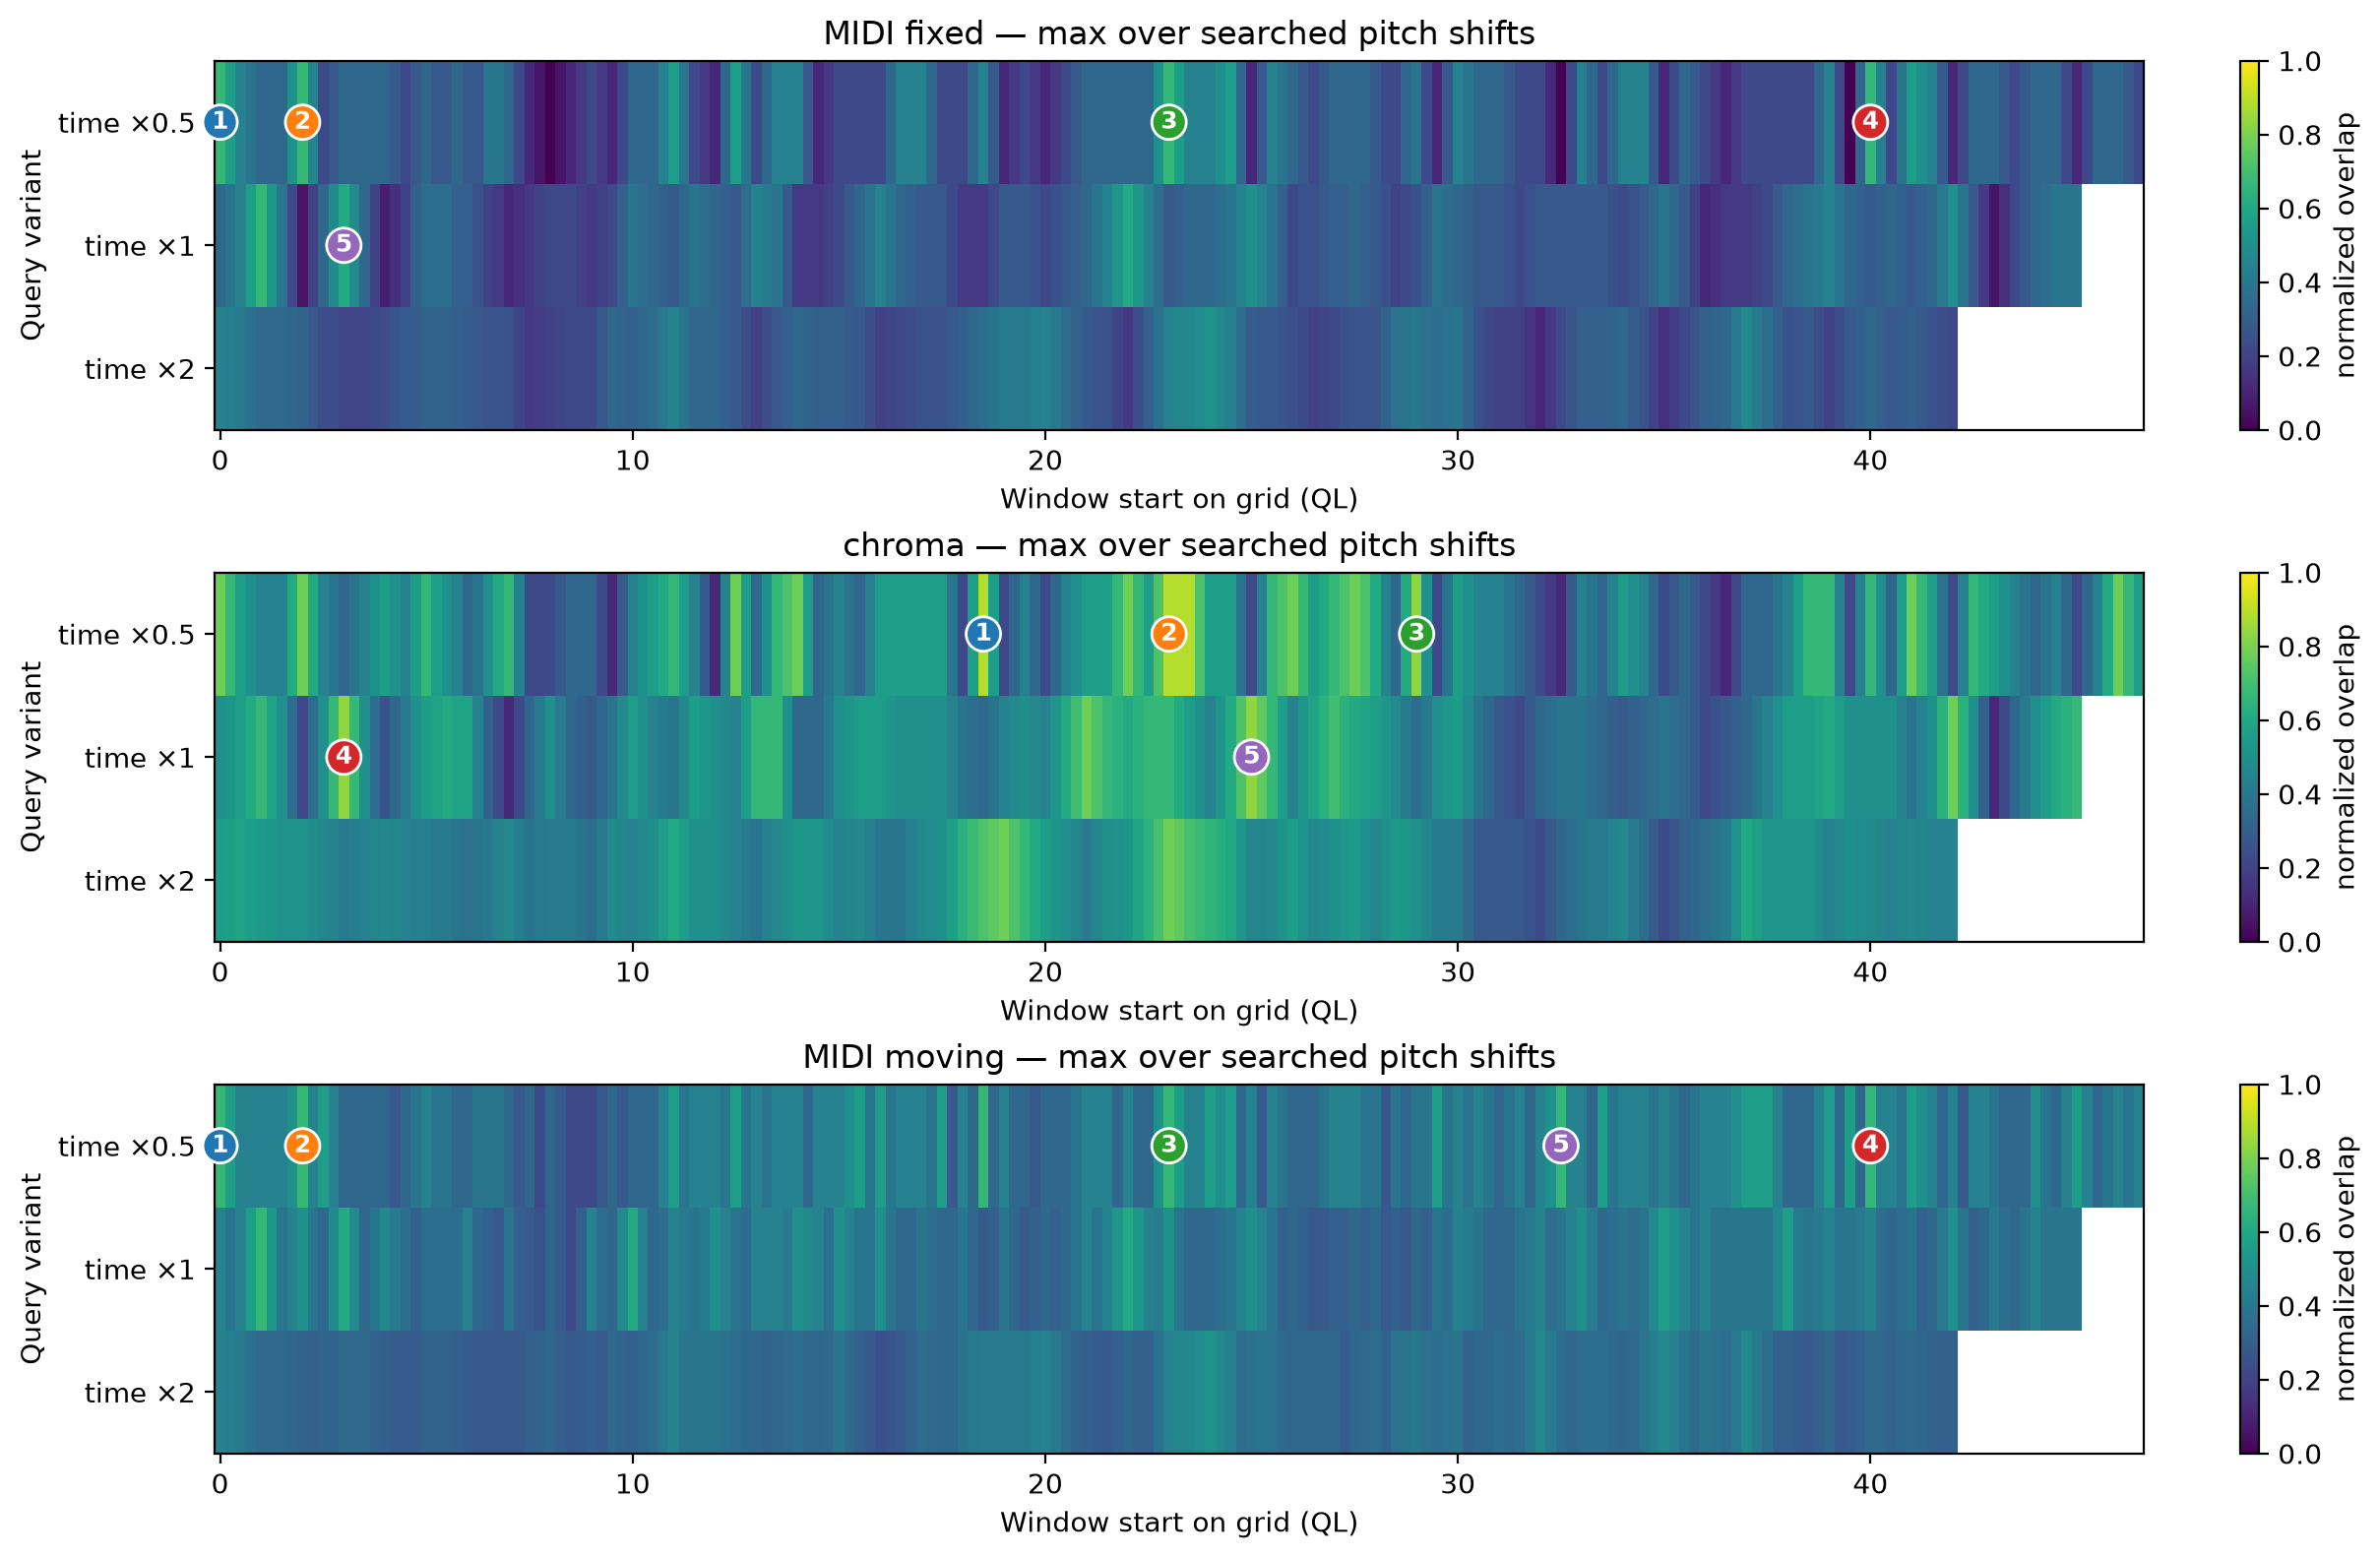

In [8]:
comparison_rows, shortlist_tables = [], []
for case, result in search_results.items():
    values = result["maps"].to_numpy()
    finite = values[np.isfinite(values)]
    comparison_rows.append({"case": case, "variants": len(result["variants"]),
                            "valid_placements": len(finite), "best_overlap": finite.max() if len(finite) else np.nan,
                            "complete_placements_before_filter": np.count_nonzero(np.isclose(finite, 1, rtol=0, atol=1e-12)),
                            "shortlisted": len(result["matches"])})
    table = result["matches"].copy()
    table.insert(0, "rank", np.arange(1, len(table)+1))
    table.insert(0, "case", case)
    table["required_cells"] = [int(result["variants"][(hit.time_scale, hit.transpose_semitones)]["kernel"].sum())
                               for hit in table.itertuples()]
    table["placed_query"] = table["transpose_semitones"].map(placed_progression)
    shortlist_tables.append(table)
comparison = pd.DataFrame(comparison_rows).set_index("case")
shortlist = pd.concat(shortlist_tables, ignore_index=True)
display(comparison.round(3))
for case, result in search_results.items():
    print(f"{case}: all returned candidates (rank colors recur below)")
    display(shortlist[shortlist["case"] == case].set_index("rank")[[
        "placed_query", "score", "loss_fraction", "shared_cells", "required_cells", "missing_cells",
        "time_scale", "transpose_semitones", "grid_onset_QL", "grid_end_QL",
        "source_onset_QL", "source_end_QL",
    ]].round(3))
    if result["matches"].empty:
        print("No candidates: inspect skipped variants or relax MIN_SCORE.")
    if not result["skipped"].empty:
        display(result["skipped"])
plot_query_heatmaps(search_results, RESOLUTION, rank=None, aggregate_transpositions=True, colors=HIT_COLORS)
plt.show()


### Inspect the moving search without pitch aggregation

This extra view shows **every pitch placement at one tempo scale**, so the
vertical search is visible directly. Unlike the overview, each row here has one
fixed semitone shift for the entire progression. Change `MAP_TIME_SCALE` to
inspect another scale. Candidate ranks and all scales remain in the overview.


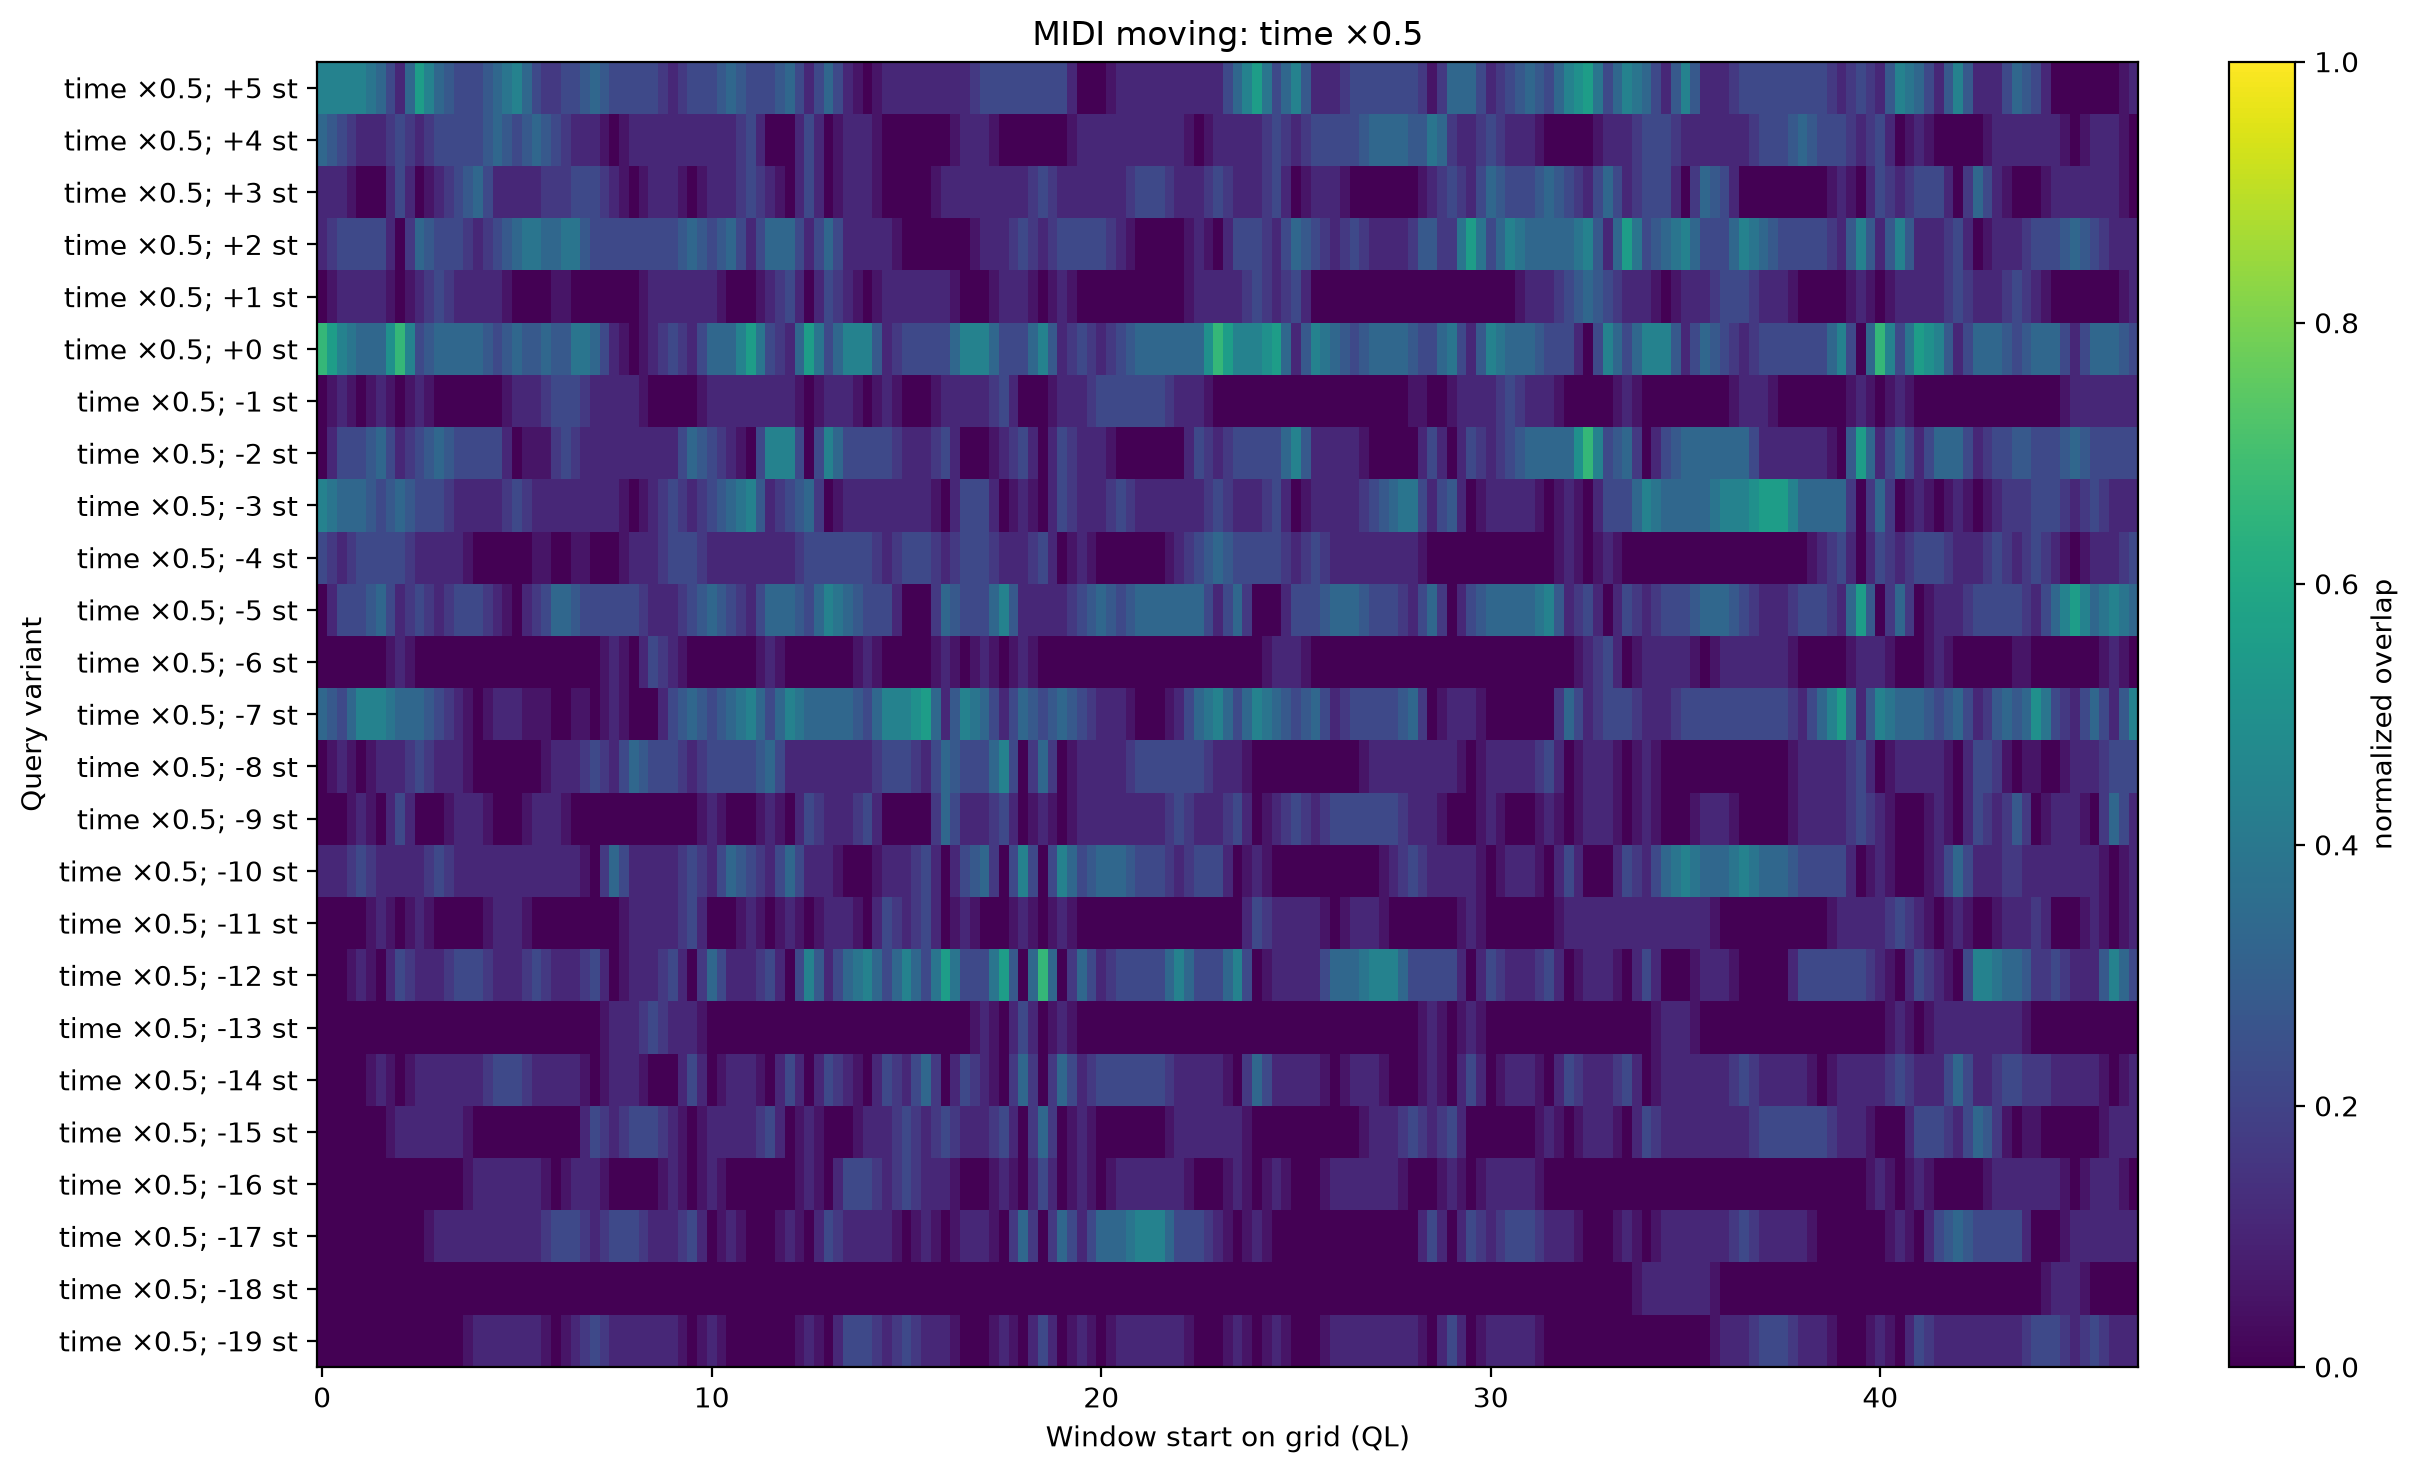

In [9]:
MAP_TIME_SCALE = TIME_SCALES[0]
moving_maps = search_results["MIDI moving"]["maps"]
scale_maps = moving_maps[moving_maps.index.get_level_values("time_scale") == MAP_TIME_SCALE]
plot_query_heatmaps({f"MIDI moving: time ×{MAP_TIME_SCALE:g}": {**search_results["MIDI moving"], "maps": scale_maps}},
                    RESOLUTION, rank=-1)
plt.show()


## 5c. How many candidates are there beyond the five displayed hits?

There are three different counts:

1. **All scored placements:** each allowed pitch shift, time scale and start.
   Overlapping windows and alternate pitch placements count separately.
2. **Above threshold:** all placements with unrounded `score ≥ threshold`.
3. **Retained windows:** those left after the same greedy time-overlap
   suppression used above, with **no top-N cap**. They are browsing candidates,
   not a proven number of independent harmonic occurrences.

`rank_query_matches` can re-filter saved placements without recomputing the
search. Even if `MIN_SCORE` hid a window from the first shortlist, it remains in
the full pool. Low thresholds also admit accidental alignments and zero-overlap
windows; we do not call every scored position a musical hit.

For our **normalized-overlap** score, define kernel loss precisely:

`loss = missing required active cells / required active cells = 1 − score`.

Thus a threshold of 0.75 permits at most 25% missing occupancy; `2/3` permits
at most 33⅓%. This is not a percentage of missing chords or source notes. Extra
source tones do not increase this loss, and the formula is not a definition of
correlation/covariance loss. Changing tempo changes the denominator: a faster
kernel can lose the same number of cells but a larger fraction of its requirements.

`REVIEW_MIN_SCORE` below controls an **uncapped review pool**, separately from
the top-five visualization. Counts use full precision: `2/3` includes a score of
2/3, whereas a literal `0.667` is slightly higher and would exclude it.


Review cutoff ≥ 0.666667; maximum missing occupancy 33.3%


,all_scored,above_review_threshold,retained_without_top_N_cap,beyond_first_five
case,,,,
MIDI fixed,537,5,4,0
chroma,537,69,19,14
MIDI moving,13425,7,6,1


raw_placements                     \
case                                 MIDI fixed MIDI moving chroma   
minimum_overlap maximum_loss_pct                                     
1.000000        0.000000                      0           0      0   
0.900000        10.000000                     0           0      0   
0.800000        20.000000                     0           0      7   
0.750000        25.000000                     0           0     23   
0.666667        33.333333                     5           7     69   
0.500000        50.000000                    24          57    255   
0.250000        75.000000                   372        1868    505   
0.000000        100.000000                  537       13425    537   

                                 retained_windows                     
case                                   MIDI fixed MIDI moving chroma  
minimum_overlap maximum_loss_pct                                      
1.000000        0.000000                        0           0      0  
0.900000        10.000000                       0           0      0  
0.800000        20.000000                       0           0      5  
0.750000        25.000000                       0           0     15  
0.666667        33.333333                       4           6     19  
0.500000        50.000000                      11          20     30  
0.250000        75.000000                      37          47     40  
0.000000        100.000000                     44          47     41

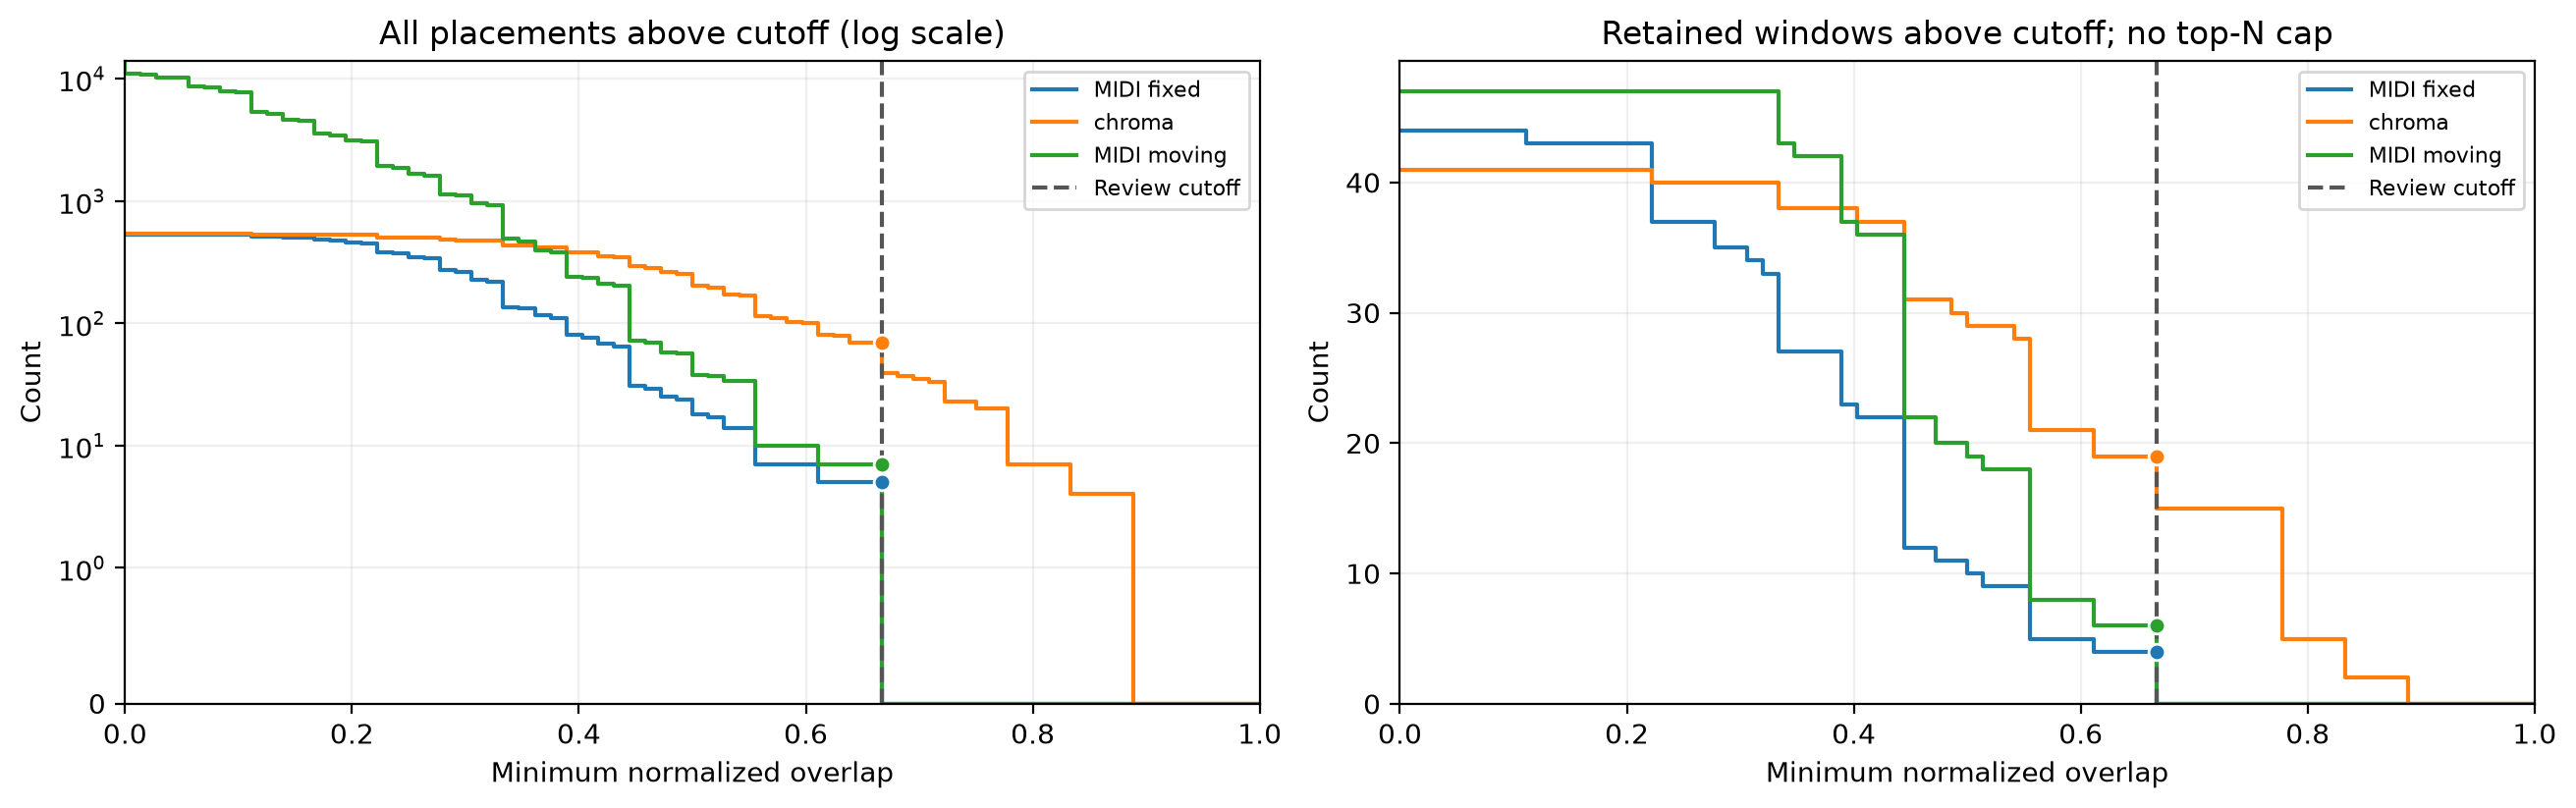

In [10]:
REVIEW_MIN_SCORE = 2 / 3
SCORE_THRESHOLDS = [1.0, 0.9, 0.8, 0.75, 2/3, 0.5, 0.25, 0.0]
all_placements = {case: result["placements"].copy() for case, result in search_results.items()}
retained_placements, review_matches = {}, {}
threshold_rows, review_summary_rows = [], []
for case, pool in all_placements.items():
    retained = rank_query_matches(pool, top_n=None, max_time_iou=MAX_TIME_IOU)
    retained_placements[case] = retained
    review = rank_query_matches(pool, top_n=None, min_score=REVIEW_MIN_SCORE, max_time_iou=MAX_TIME_IOU)
    review["placed_query"] = review["transpose_semitones"].map(placed_progression)
    review_matches[case] = review
    review_summary_rows.append({"case": case, "all_scored": len(pool),
                                "above_review_threshold": int((pool["score"] >= REVIEW_MIN_SCORE).sum()),
                                "retained_without_top_N_cap": len(review),
                                "beyond_first_five": max(0, len(review) - 5)})
    for threshold in SCORE_THRESHOLDS:
        threshold_rows.append({"case": case, "minimum_overlap": threshold,
                               "maximum_loss_pct": 100*(1-threshold),
                               "raw_placements": int((pool["score"] >= threshold).sum()),
                               "retained_windows": int((retained["score"] >= threshold).sum())})
threshold_report = pd.DataFrame(threshold_rows)
print(f"Review cutoff ≥ {REVIEW_MIN_SCORE:.6f}; maximum missing occupancy {1-REVIEW_MIN_SCORE:.1%}")
display(pd.DataFrame(review_summary_rows).set_index("case"))
display(threshold_report.set_index(["minimum_overlap", "maximum_loss_pct", "case"]).unstack("case").sort_index(ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout="constrained")
for case in search_results:
    for ax, pool in zip(axes, [all_placements[case], retained_placements[case]]):
        scores = pool["score"].to_numpy(dtype=float)
        thresholds = np.unique(np.r_[0, scores, 1])
        counts = [np.count_nonzero(scores >= value) for value in thresholds]
        line, = ax.step(thresholds, counts, where="pre", label=case)
        ax.scatter(REVIEW_MIN_SCORE, np.count_nonzero(scores >= REVIEW_MIN_SCORE),
                   color=line.get_color(), edgecolor="white", zorder=4)
for ax, label in zip(axes, ["All placements above cutoff (log scale)", "Retained windows above cutoff; no top-N cap"]):
    ax.axvline(REVIEW_MIN_SCORE, color="#555555", linestyle="--", label="Review cutoff")
    ax.set(title=label, xlabel="Minimum normalized overlap", ylabel="Count", xlim=(0, 1))
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
axes[0].set_yscale("symlog", linthresh=1)  # keeps zero visible
axes[0].set_ylim(bottom=0)
axes[1].set_ylim(bottom=0)
plt.show()


### Browse the candidates that the top-five view did not show

This is a page of the uncapped, overlap-filtered review pool. Its ranks belong
to that pool, not necessarily to the original shortlist. By default it starts
at **rank 6**. The printed count refers to the entire pool, not just this page.
Change the review cutoff above, or `BROWSE_CASE` / `BROWSE_START_RANK` below.
To trace one of these candidates through its binary window, source notes and
score, select `INSPECT_POOL="threshold review"` with its rank in §6.


In [11]:
BROWSE_CASE = "chroma"
BROWSE_START_RANK = 6
BROWSE_PAGE_SIZE = 10
if BROWSE_CASE not in review_matches or BROWSE_START_RANK < 1 or BROWSE_PAGE_SIZE < 1:
    raise ValueError("Choose an available case and positive rank/page size.")
review_page = review_matches[BROWSE_CASE].copy()
review_page.index = pd.RangeIndex(1, len(review_page)+1, name="review_rank")
review_page = review_page.iloc[BROWSE_START_RANK-1:BROWSE_START_RANK-1+BROWSE_PAGE_SIZE]
print(f"{BROWSE_CASE}: {len(review_matches[BROWSE_CASE])} retained candidates at cutoff {REVIEW_MIN_SCORE:.6f}; "
      f"displaying {len(review_page)} on this page.")
display(review_page[["placed_query", "score", "loss_fraction", "shared_cells", "required_cells", "missing_cells",
                     "time_scale", "transpose_semitones", "grid_onset_QL", "grid_end_QL"]].round(3))
if review_page.empty:
    print("No candidates on this page; lower the review cutoff or start at an earlier rank.")


chroma: 19 retained candidates at cutoff 0.666667; displaying 10 on this page.


,placed_query,score,loss_fraction,shared_cells,required_cells,missing_cells,time_scale,transpose_semitones,grid_onset_QL,grid_end_QL
review_rank,,,,,,,,,,
6,D major → A major → D major,0.778,0.222,14,18,4,0.5,0,0.0,1.5
7,D major → A major → D major,0.778,0.222,14,18,4,0.5,0,2.0,3.5
8,D major → A major → D major,0.778,0.222,14,18,4,0.5,0,12.5,14.0
9,D major → A major → D major,0.778,0.222,14,18,4,0.5,0,14.0,15.5
10,D major → A major → D major,0.778,0.222,14,18,4,0.5,0,22.0,23.5
11,D major → A major → D major,0.778,0.222,14,18,4,0.5,0,27.5,29.0
12,D major → A major → D major,0.778,0.222,14,18,4,0.5,0,41.0,42.5
13,D major → A major → D major,0.778,0.222,14,18,4,0.5,0,46.0,47.5
14,D major → A major → D major,0.778,0.222,28,36,8,1.0,0,42.0,45.0


## 6. Recover every shortlisted hit, then inspect one binary window

Every candidate gets its own kernel variant, raw placement and provenance
trace. The next section projects **all of these traces** into the piano roll
and score, not just the best result. A near hit is useful because we can ask
which requirements it satisfies and which are missing.

For a detailed cell-by-cell inspection choose `INSPECT_CASE` and the **1-based**
`INSPECT_RANK` from the shortlist. Chroma is the default because it allows other
voicings. Magenta outlines mark shared requirements; red crosses mark missing
ones. Chroma's y-axis is pitch class, not MIDI register. Both panels use grid
time. The selected MIDI kernel is shown at its actual placed pitches.

`INSPECT_POOL="shortlist"` uses the original top-five result. Choose
`"threshold review"` to inspect any rank in the larger uncapped pool above.
The selected pool, case, rank and time range will be repeated immediately above
the stage table in §8, so its scope is explicit.


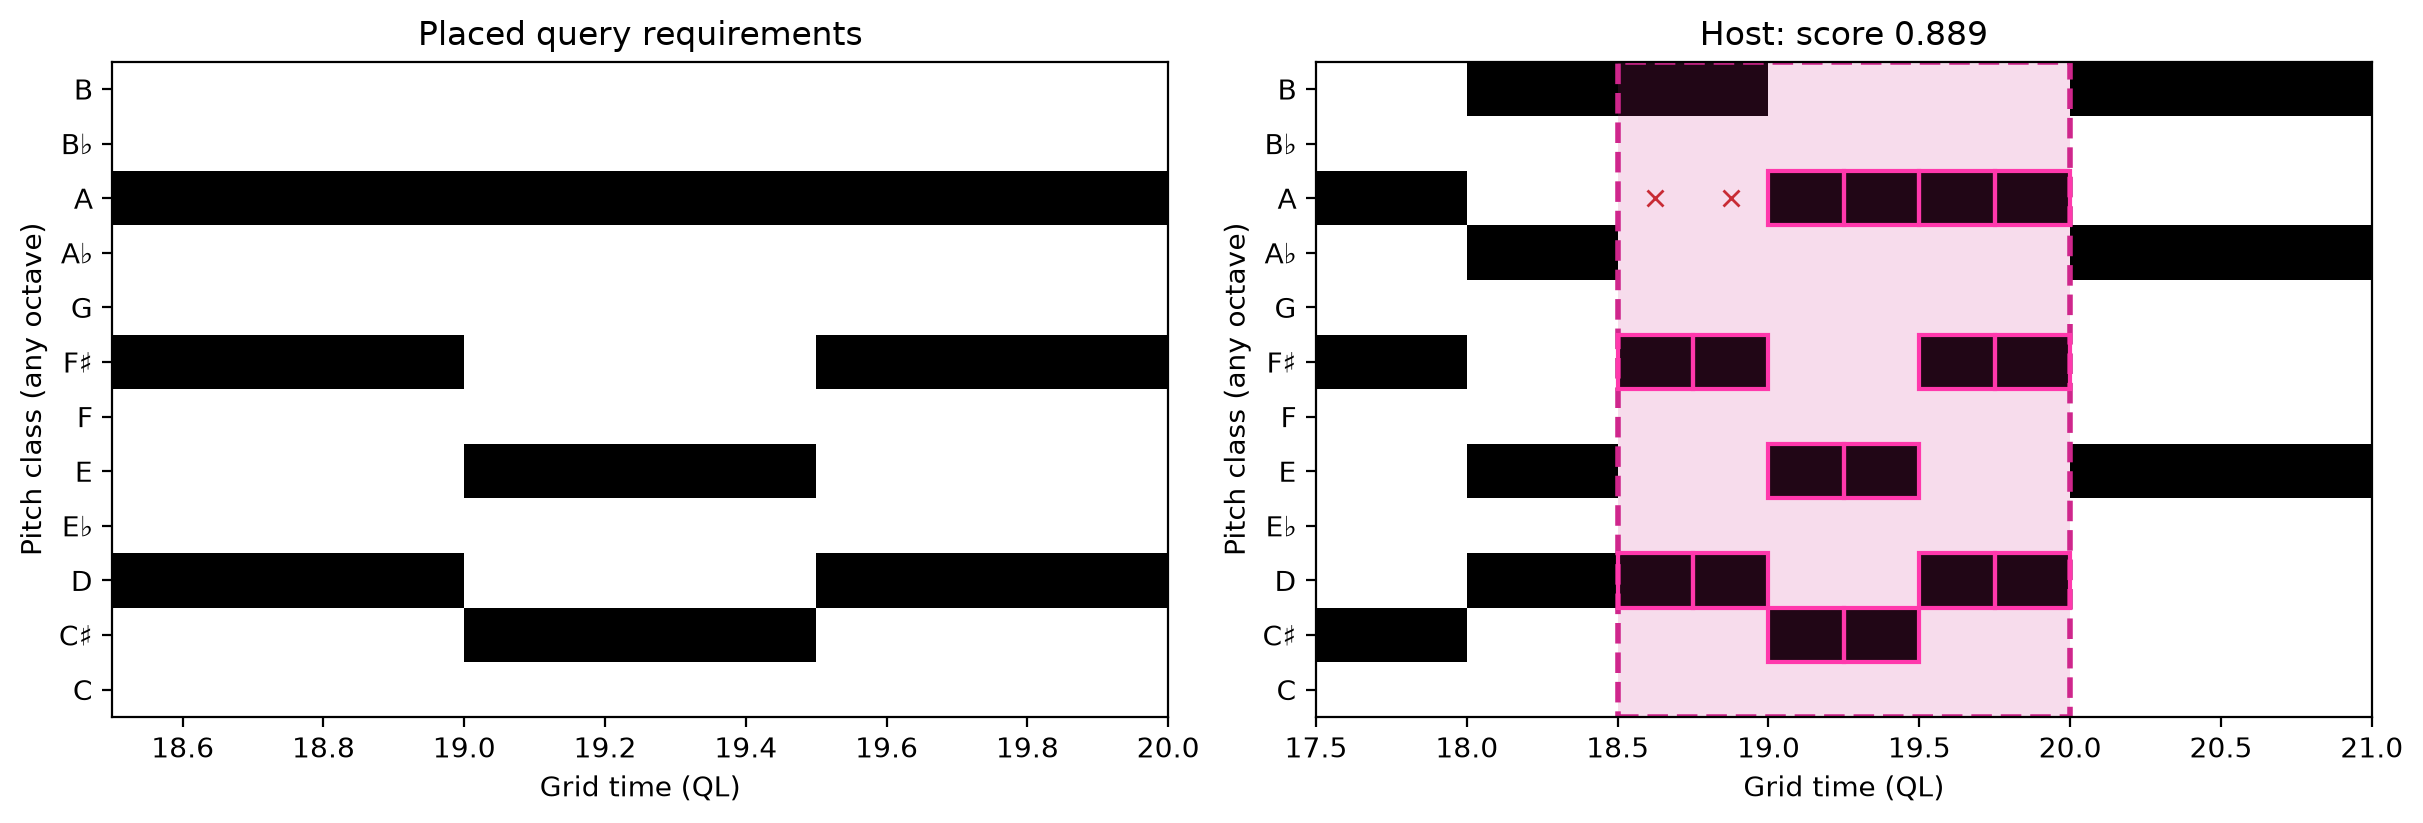

chroma / shortlist #1: shift +0 st, 18.5–20 grid QL; 17.5–19 source QL
Placed query: D major → A major → D major
Shared 16/18 required cells; missing 2 cells.


In [12]:
hit_traces = {}
membership_parts = []
for case, result in search_results.items():
    hit_traces[case] = []
    for rank, hit in enumerate(result["matches"].itertuples(), start=1):
        variant = result["variants"][(hit.time_scale, hit.transpose_semitones)]
        candidate_trace = binary_match_sources(case_hosts[case], variant["kernel"], hit.row, hit.col)
        hit_traces[case].append(candidate_trace)
        contributing = candidate_trace["matched_notes"].copy()
        if not contributing.empty:
            contributing.insert(0, "hit_rank", rank)
            contributing.insert(0, "case", case)
            membership_parts.append(contributing)
hit_note_membership = (pd.concat(membership_parts, ignore_index=True) if membership_parts else
                       pd.DataFrame(columns=["case", "hit_rank", "xml_id"]))

INSPECT_CASE = "chroma"  # "MIDI fixed" | "chroma" | "MIDI moving"
INSPECT_POOL = "shortlist"  # "shortlist" | "threshold review"
INSPECT_RANK = 1  # ranks in displayed tables are 1-based
if INSPECT_CASE not in search_results:
    raise ValueError(f"Choose a case from {list(search_results)}.")
HIT_RANK = INSPECT_RANK - 1  # plotting helpers accept a zero-based position
if INSPECT_POOL not in {"shortlist", "threshold review"}:
    raise ValueError("Choose shortlist or threshold review.")
inspection_matches = (search_results[INSPECT_CASE]["matches"] if INSPECT_POOL == "shortlist" else review_matches[INSPECT_CASE])
selected_result = {**search_results[INSPECT_CASE], "matches": inspection_matches}
selected_host = case_hosts[INSPECT_CASE]
SELECTED_LABEL = f"{INSPECT_CASE} / {INSPECT_POOL} #{INSPECT_RANK}"
selected_hit = trace = selected_kernel = None
if not 0 <= HIT_RANK < len(selected_result["matches"]):
    print("No candidate at this rank; choose an available rank or relax the filters.")
else:
    selected_hit = selected_result["matches"].iloc[HIT_RANK]
    key = (selected_hit["time_scale"], selected_hit["transpose_semitones"])
    selected_kernel = selected_result["variants"][key]["kernel"]
    trace = binary_match_sources(selected_host, selected_kernel, selected_hit["row"], selected_hit["col"])
    plot_binary_query_match(selected_host, selected_result, rank=HIT_RANK)
    plt.show()
    print(f"{SELECTED_LABEL}: shift {selected_hit['transpose_semitones']:+g} st, "
          f"{selected_hit['grid_onset_QL']:g}–{selected_hit['grid_end_QL']:g} grid QL; "
          f"{selected_hit['source_onset_QL']:g}–{selected_hit['source_end_QL']:g} source QL")
    print("Placed query:", placed_progression(selected_hit["transpose_semitones"]))
    print(f"Shared {trace['raw_overlap']:.0f}/{selected_kernel.sum():.0f} required cells; "
          f"missing {len(trace['missing_cells'])} cells.")


### Hold the time and tempo fixed; compare allowed pitch placements

At the selected passage's start and scale, how well does each of the three
questions score? Fixed MIDI and chroma retain shift 0; moving MIDI takes its
best valid shift **at this same time**, reported explicitly below. This is not
a comparison of each case's unrelated best passage. The moving case must be
at least as good as fixed MIDI wherever the fixed band is valid, because it
includes that placement. Chroma and moving MIDI relax different constraints,
so neither is generally guaranteed to beat the other.


In [13]:
same_placement = []
if selected_hit is not None:
    scale, col = selected_hit["time_scale"], int(selected_hit["col"])
    for case, result in search_results.items():
        maps = result["maps"]
        candidates = (maps.loc[maps.index.get_level_values("time_scale") == scale, col].dropna()
                      if col in maps.columns else pd.Series(dtype=float))
        if candidates.empty:
            same_placement.append({"case": case, "overlap": np.nan, "status": "no valid placement at this time/scale"})
            continue
        key = candidates.idxmax()
        variant = result["variants"][key]
        comparison_trace = binary_match_sources(case_hosts[case], variant["kernel"], variant["row"], col)
        same_placement.append({"case": case, "overlap": comparison_trace["score"], "best_allowed_shift_st": key[1],
                               "placed_query": placed_progression(key[1]),
                               "shared_cells": int(comparison_trace["raw_overlap"]),
                               "required_cells": int(variant["kernel"].sum()),
                               "source_notes": len(comparison_trace["matched_notes"]), "status": "same time and scale"})
    display(pd.DataFrame(same_placement).set_index("case").round(3))


,overlap,best_allowed_shift_st,placed_query,shared_cells,required_cells,source_notes,status
case,,,,,,,
MIDI fixed,0.444,0,D major → A major → D major,8,18,4,same time and scale
chroma,0.889,0,D major → A major → D major,16,18,10,same time and scale
MIDI moving,0.667,-12,D major → A major → D major,12,18,6,same time and scale


## 7. Show ALL top hits in source piano rolls and original notation

Each of the three cases has a full-score piano-roll overview with **every
returned window**, numbered and colored by rank. The filled box shows the area
tested, not an assertion that the whole passage matches. MIDI boxes use their
actual placed pitch band; chroma boxes span the source register because octaves
were ignored. Colored notes contributed to shared query cells. Other notes stay
visible, and missing requirements remain absent.

The same ranks/colors then identify all contributing notes in complete original
Verovio score pages, preserving clefs, key, meter, rests and other voices.
**Gray notes contribute to multiple shortlisted hits within that case**; the
membership table lists those ranks explicitly. Original notes retain their full
durations, even if only part overlaps a query. Shared beams remain in their
original color so they do not incorrectly imply membership for neighboring notes.

The shortlists below are starting points for harmony analysis, including weak
or incomplete matches. To examine any one of them in detail, set its case/rank
in §6 and read the missing-requirement report in §8.


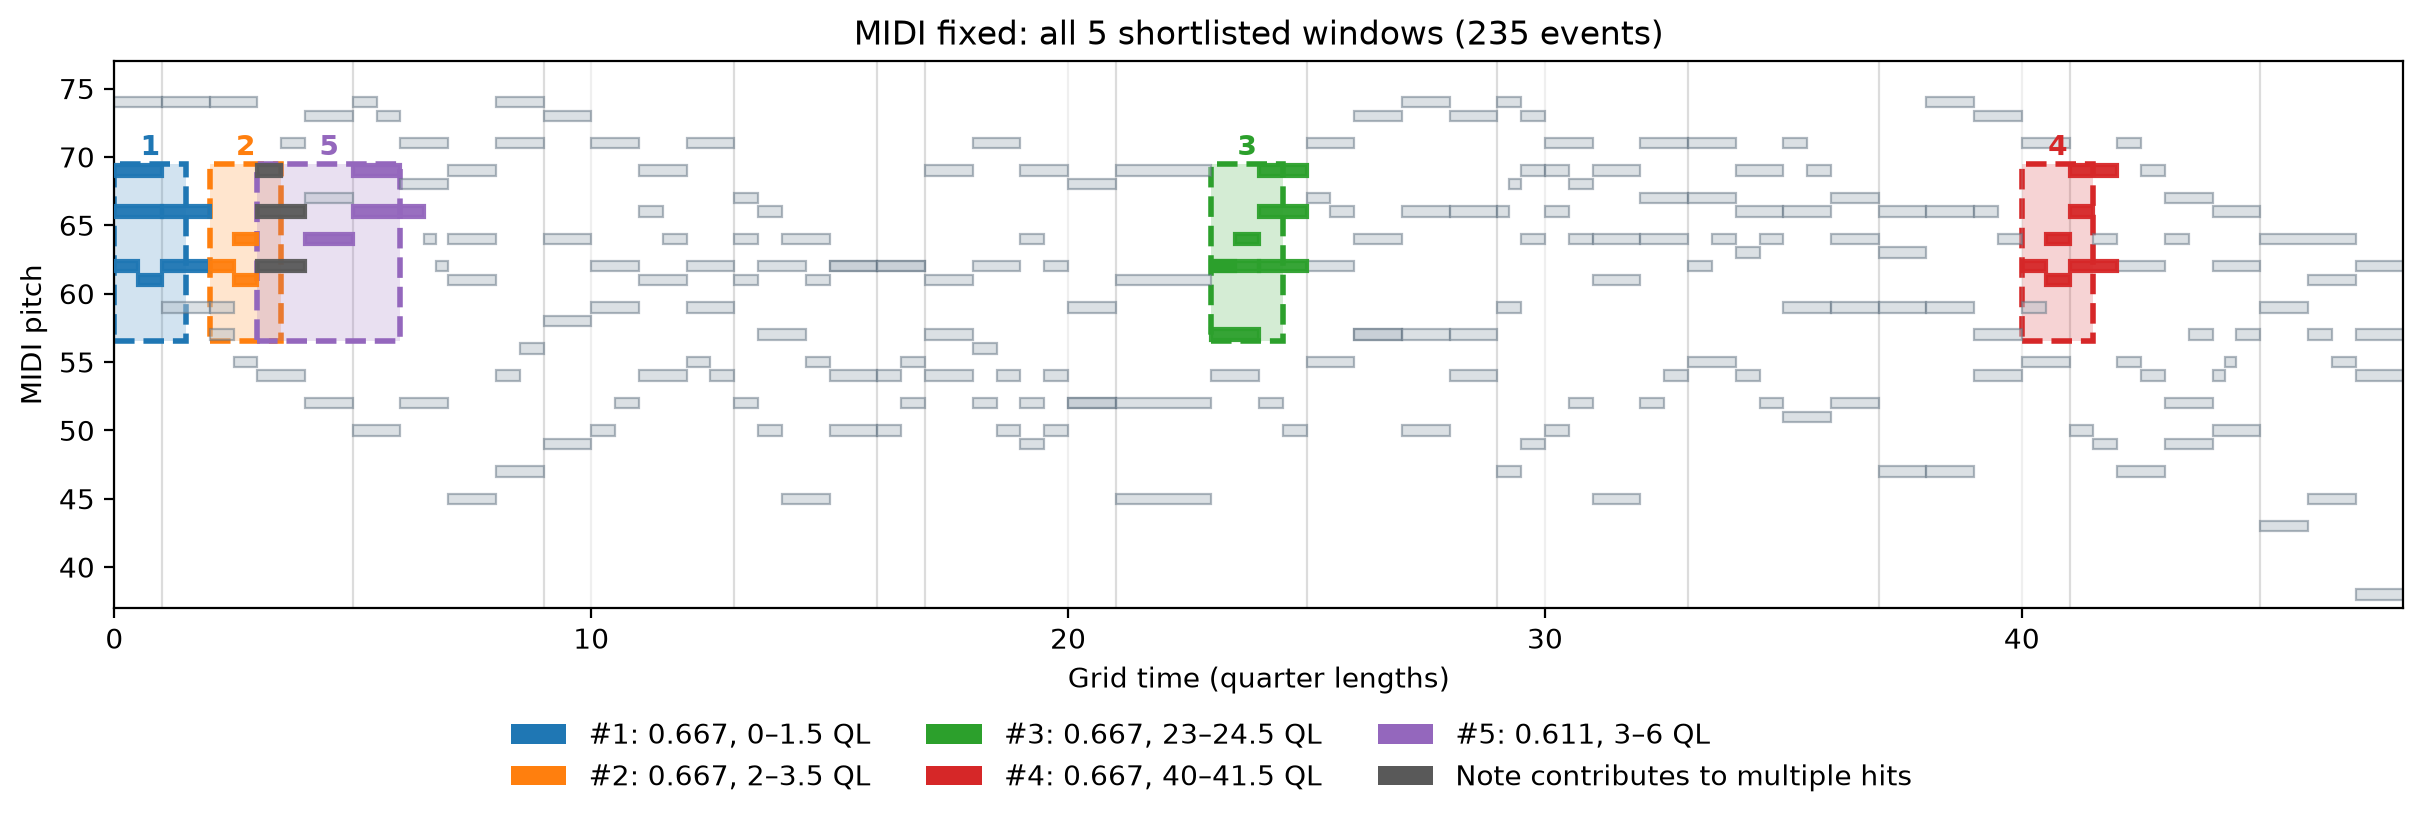

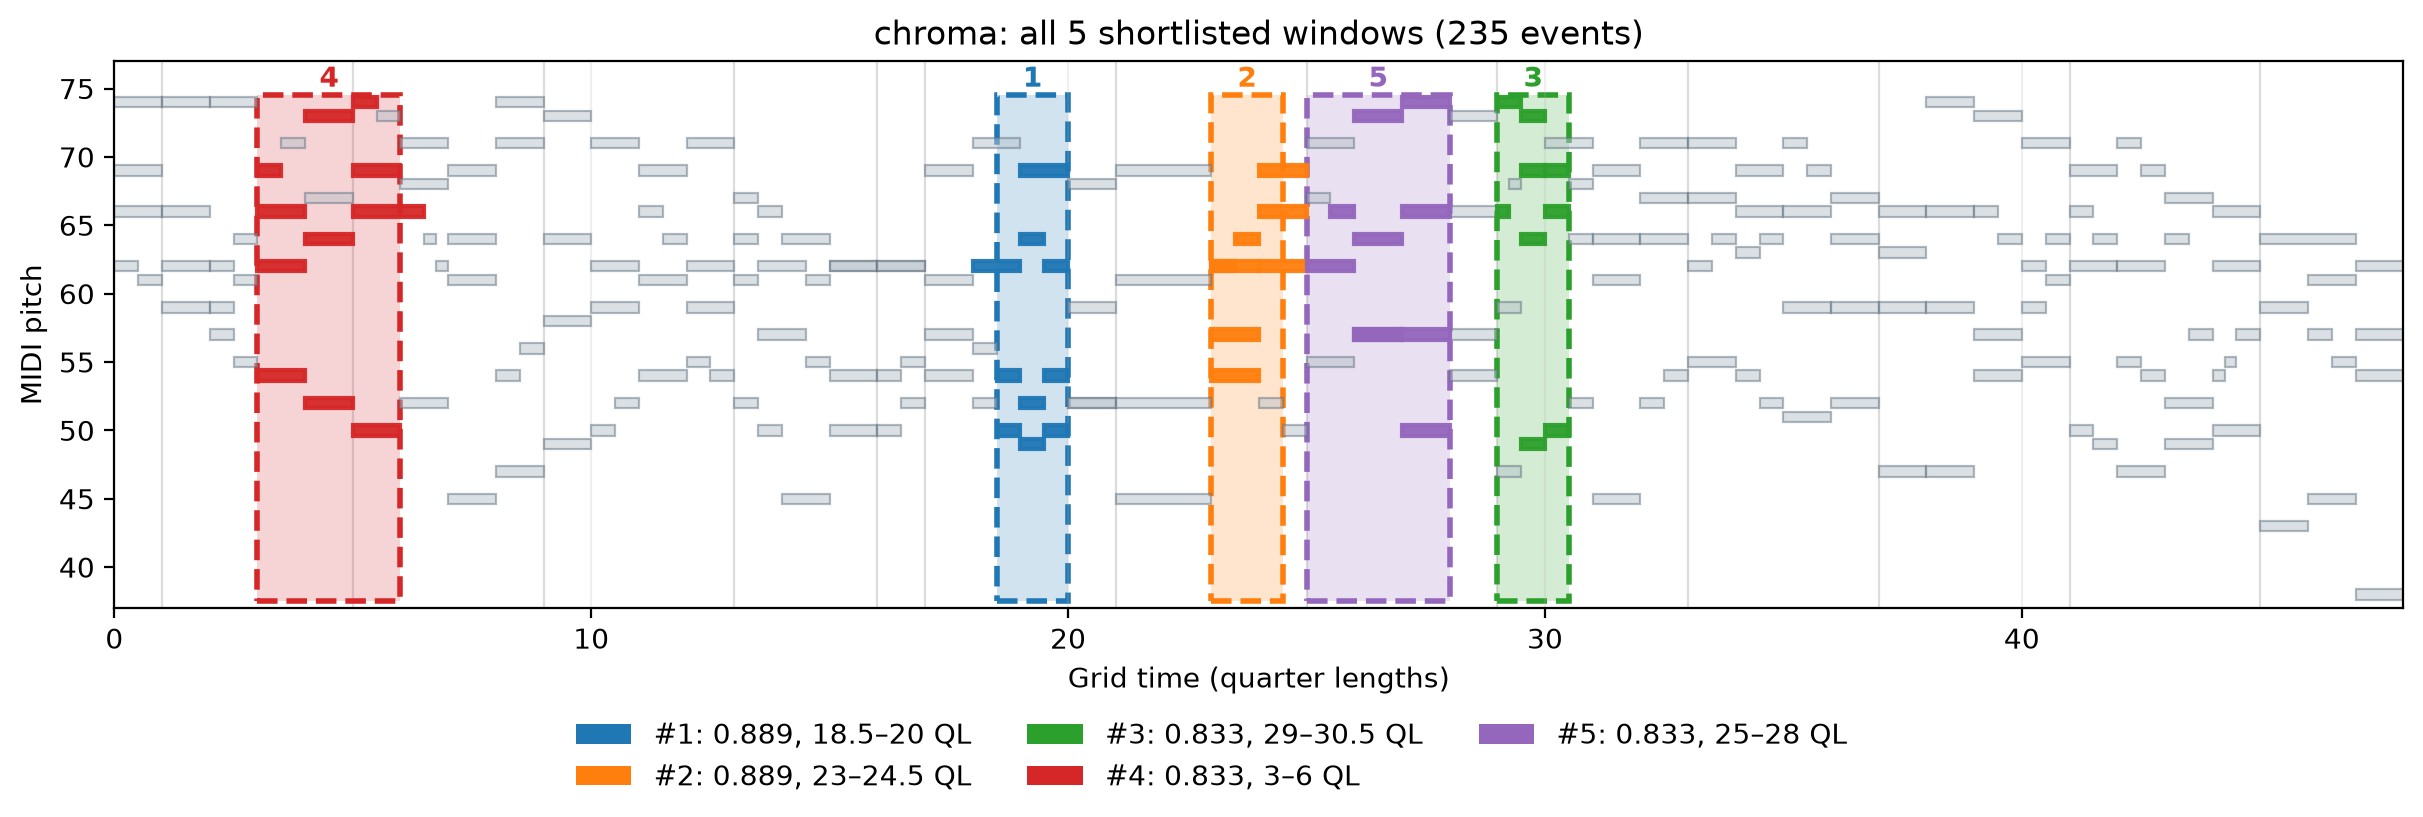

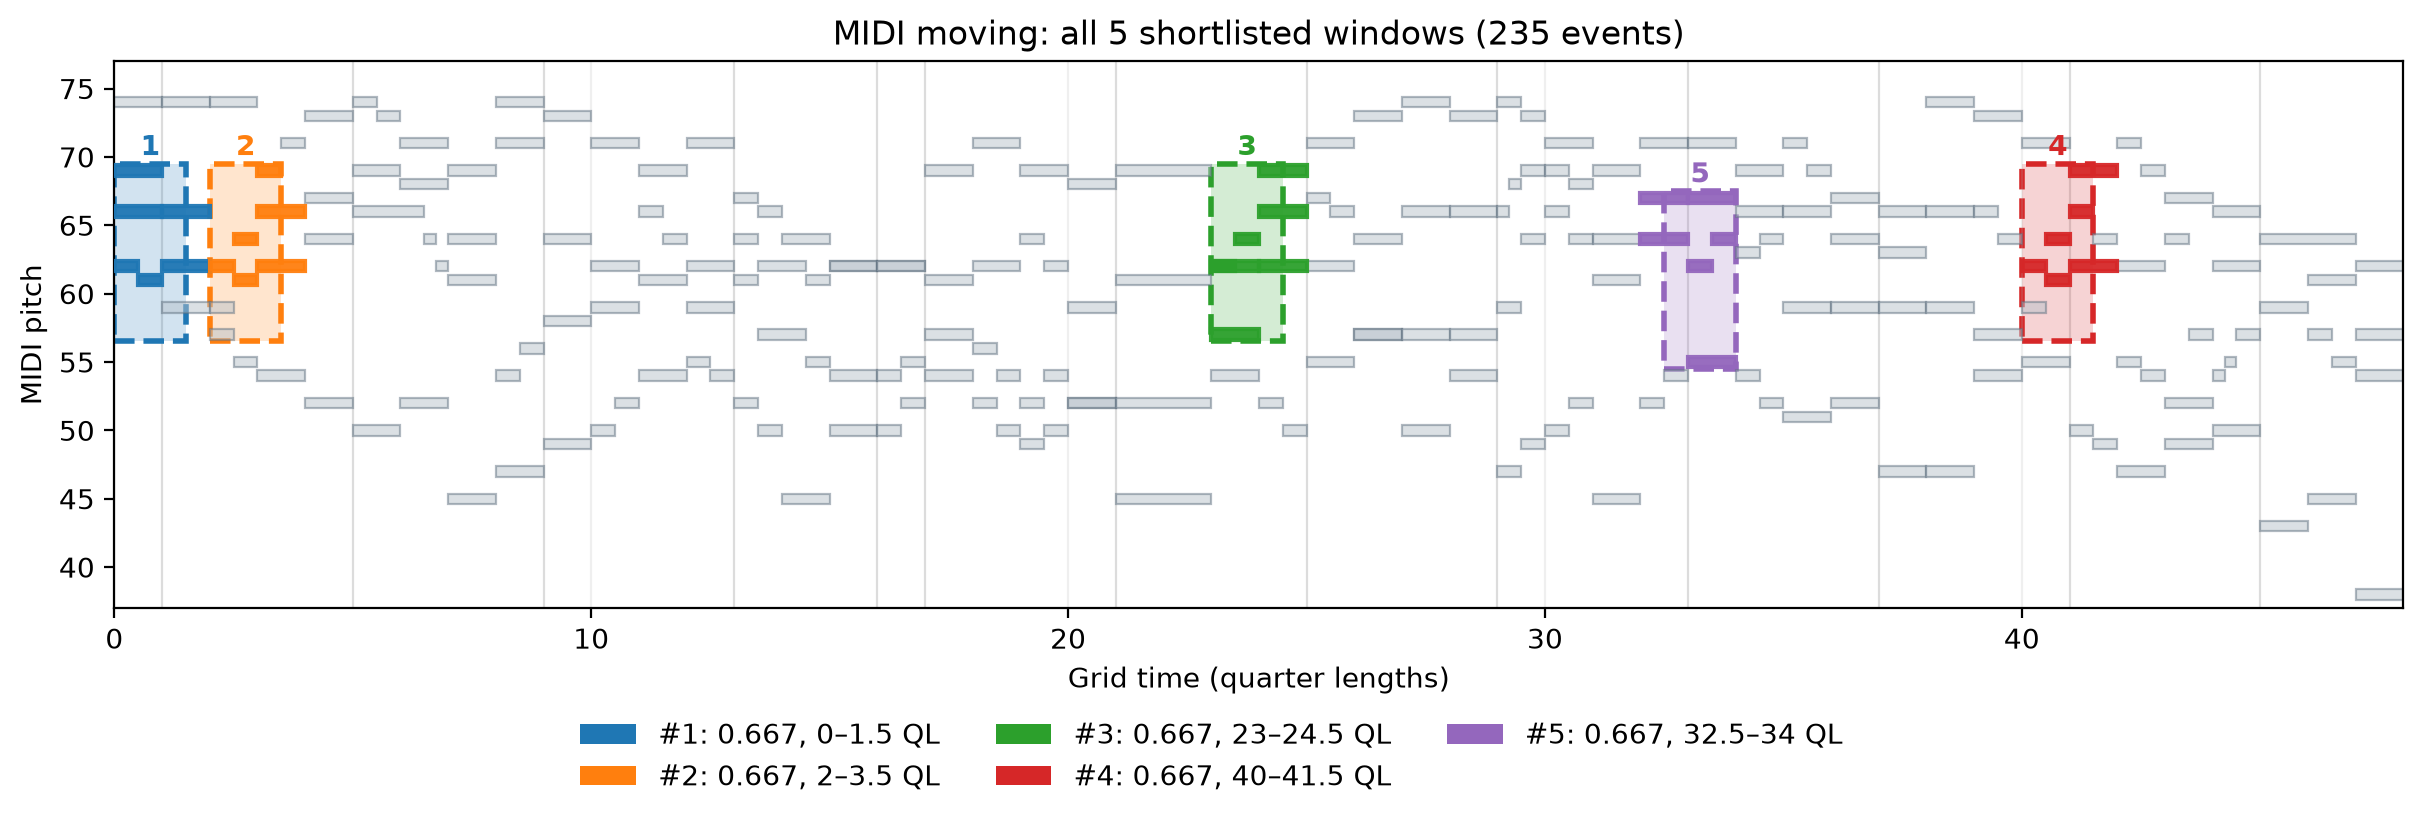

Notes shown in gray (full note-to-hit provenance is in hit_note_membership):


,case,xml_id,hit_ranks
0,MIDI fixed,d1e414,"[2, 5]"
1,MIDI fixed,d1e533,"[2, 5]"
2,MIDI fixed,d1e57,"[2, 5]"


In [14]:
for case, traces in hit_traces.items():
    plot_matched_sources(case_hosts[case], traces, context_notes=notes, colors=HIT_COLORS,
                         shared_color=SHARED_COLOR, title=f"{case}: all {len(traces)} shortlisted windows")
    plt.show()

note_memberships = {}
for case in search_results:
    members = hit_note_membership[hit_note_membership["case"] == case]
    note_memberships[case] = members.groupby("xml_id")["hit_rank"].agg(lambda values: sorted(set(values))).to_dict()
shared_membership = pd.DataFrame([
    {"case": case, "xml_id": pointer, "hit_ranks": ranks}
    for case, memberships in note_memberships.items() for pointer, ranks in memberships.items() if len(ranks) > 1
], columns=["case", "xml_id", "hit_ranks"])
print("Notes shown in gray (full note-to-hit provenance is in hit_note_membership):")
display(shared_membership)


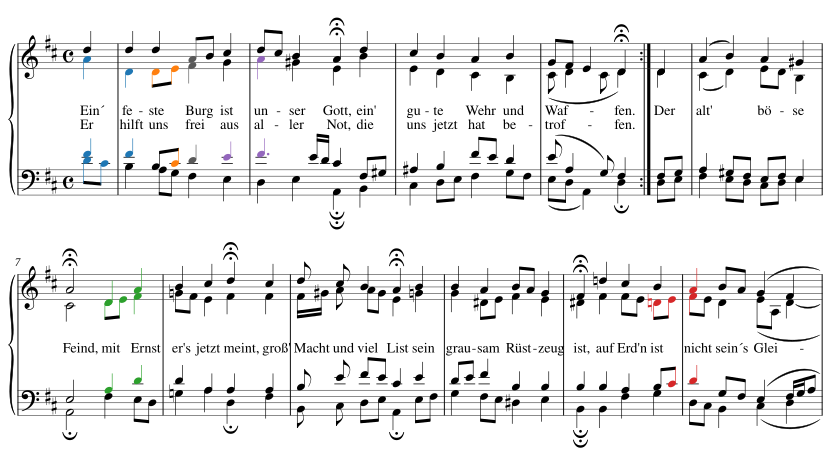

28 distinct contributing notes; 1 complete source page(s).


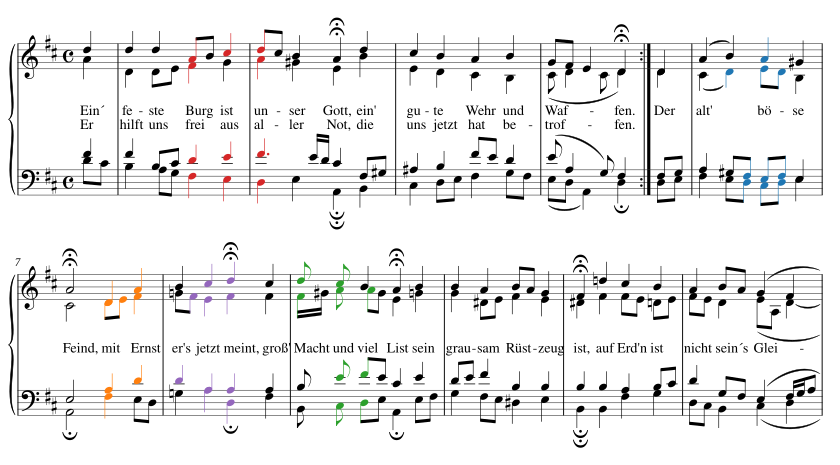

48 distinct contributing notes; 1 complete source page(s).


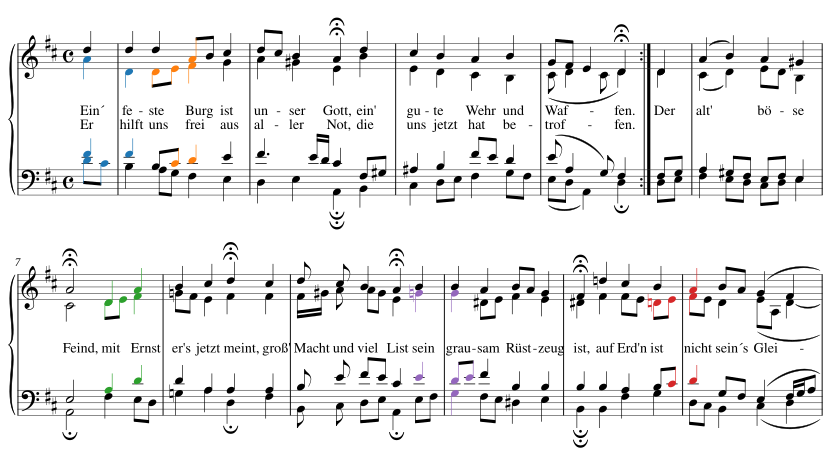

31 distinct contributing notes; 1 complete source page(s).


In [15]:
RUN_SOURCE_NOTATION = True
context_svgs = {}
if RUN_SOURCE_NOTATION:
    source_mei = mei_path.read_text(encoding="utf-8")
    with vrv_quiet():
        vrv_set_options(pageWidth=2400, pageHeight=1600, scale=35, breaks="auto",
                        adjustPageHeight=True, header="auto", removeIds=False, xmlIdSeed=0)
        vrv_load_from_file(str(mei_path))
        for case, result in search_results.items():
            memberships = note_memberships[case]
            display(HTML(f"<h3>{escape(case)} — all {len(result['matches'])} shortlisted hits</h3>"))
            legend = []
            for rank, hit in enumerate(result["matches"].itertuples(), start=1):
                legend.append(f'<span style="color:{HIT_COLORS[rank-1]}; margin-right:18px; white-space:nowrap">'
                              f'■ #{rank}: {hit.score:.3f}, grid {hit.grid_onset_QL:g}–{hit.grid_end_QL:g} QL, '
                              f'{hit.transpose_semitones:+g} st; {escape(placed_progression(hit.transpose_semitones))}</span>')
            if any(len(ranks) > 1 for ranks in memberships.values()):
                legend.append(f'<span style="color:{SHARED_COLOR}">■ Shared note (see membership table)</span>')
            display(HTML('<div style="line-height:2">' + ' '.join(legend) + '</div>'))
            if not memberships:
                context_svgs[case] = []
                print("No contributing notes to highlight; a zero-overlap candidate has no source-note evidence.")
                continue
            note_colors = {pointer: HIT_COLORS[ranks[0]-1] if len(ranks) == 1 else SHARED_COLOR
                           for pointer, ranks in memberships.items()}
            context_svgs[case] = vrv_render_source_context(
                list(memberships), mei_xml=source_mei, highlight_colors=note_colors,
                selected_pages_only=True, display=True,
            )
            print(f"{len(memberships)} distinct contributing notes; {len(context_svgs[case])} complete source page(s).")
else:
    print("Source rendering disabled; piano rolls and hit_note_membership remain available.")


## 8. Explain ONE selected hit, stage by stage

**This table describes exactly one hit: the case, pool and rank selected in §6.**
It is not an average over the five hits, a ranking of three hits, or a summary of
the whole score. Each row is one successive chord stage **inside that single
window**. The identity and placed chord sequence are printed directly above it.

For the default **chroma / shortlist #1** (grid **18.5–20 QL**, time ×0.5,
shift 0), each chord lasts 0.5 QL. At resolution 0.25 QL, each requested pitch
class occupies **two columns**. Three tones × two columns = **six required
cells per chord**, eighteen for the entire query.

- Stage 1 requests D, F♯ and A. Four of its six cells are present; the two missing
  cells are both A, covering **0.5 QL of A occupancy**. Its overlap is 4/6.
- Stages 2 and 3 each supply all six requested cells, so their overlaps are 1.
- The **whole hit** supplies **(4 + 6 + 6) / (6 + 6 + 6) = 16/18 = 0.889**,
  with **2/18 = 11.1% loss**. The first row's 0.667 is not this hit's total score.

Those numbers explain the saved default example. If you change the source,
query or selection, use the computed identity/table below. Totals are weighted
by required cells; a simple mean of stage scores is only valid when their
denominators are equal. The displayed stage intervals are actual grid times.

`placed_chord` names the **query at this transposition**, not a confirmed chord
in the source. In moving MIDI at −2, the rows become C major, G major, C major.
That is the transposed I–V–I / T–D–T template; a partial occupancy score still
does not prove those complete chords or their harmonic functions in context.


In [16]:
stage_report = []
if trace is None:
    print("No selected candidate to explain. Choose an available pool/case/rank in §6.")
else:
    display(HTML(f"<h3>One hit only: {escape(SELECTED_LABEL)}</h3>"))
    identity = {"case": INSPECT_CASE, "pool": INSPECT_POOL, "rank": INSPECT_RANK,
                "placed_query": placed_progression(selected_hit["transpose_semitones"])}
    identity.update({name: selected_hit[name] for name in ["grid_onset_QL", "grid_end_QL", "source_onset_QL",
                    "source_end_QL", "time_scale", "transpose_semitones", "score", "loss_fraction"]})
    display(pd.DataFrame([identity]).round(3))
    row, col = int(selected_hit["row"]), int(selected_hit["col"])
    actual = selected_host.matrix[row:row+selected_kernel.shape[0], col:col+selected_kernel.shape[1]]
    scale = float(selected_hit["time_scale"])
    placed_names = placed_chord_names(selected_hit["transpose_semitones"])
    for (stage, info), placed_name in zip(progression.iterrows(), placed_names):
        query_edges = np.rint(np.array([info["start_QL"], info["end_QL"]]) / RESOLUTION)
        start, end = np.rint(query_edges * scale).astype(int)
        required = int(selected_kernel[:, start:end].sum())
        shared = int((selected_kernel[:, start:end] * actual[:, start:end]).sum())
        missing_counts = np.count_nonzero((selected_kernel[:, start:end] > 0) & (actual[:, start:end] == 0), axis=1)
        missing_labels = []
        for query_row in np.flatnonzero(missing_counts):
            axis_value = selected_host.meta["row_axis_values"][row + query_row]
            label = str(axis_value) if selected_host.meta["y_mode"] == "chroma" else midi_to_name(int(axis_value))
            missing_labels.append(f"{label}: {missing_counts[query_row] * RESOLUTION:g} QL")
        stage_report.append({"stage": stage, "placed_chord": placed_name,
                             "grid_start_QL": (col+start)*RESOLUTION, "grid_end_QL": (col+end)*RESOLUTION,
                             "required_cells": required, "shared_cells": shared, "missing_cells": required-shared,
                             "overlap": shared/required if required else np.nan,
                             "loss_pct": 100*(required-shared)/required if required else np.nan,
                             "missing_requirements": "; ".join(missing_labels) or ("none" if required else "stage erased by quantization")})
    stage_table = pd.DataFrame(stage_report).set_index("stage")
    total_required, total_shared = int(stage_table["required_cells"].sum()), int(stage_table["shared_cells"].sum())
    total_missing = total_required - total_shared
    assert total_required == selected_kernel.sum()
    assert total_shared == trace["raw_overlap"]
    display(stage_table.round(3))
    display(HTML(
        f"<p><b>Whole selected hit:</b> shared {total_shared}/{total_required} = {total_shared/total_required:.3f}; "
        f"missing {total_missing}/{total_required} = <b>{total_missing/total_required:.1%} loss</b>.</p>"
        "<p>Loss counts missing pitch/class × time cells, not missing source notes or complete chords.</p>"
    ))


,case,pool,rank,placed_query,grid_onset_QL,grid_end_QL,source_onset_QL,source_end_QL,time_scale,transpose_semitones,score,loss_fraction
0,chroma,shortlist,1,D major → A major → D major,18.5,20.0,17.5,19.0,0.5,0.0,0.889,0.111


,placed_chord,grid_start_QL,grid_end_QL,required_cells,shared_cells,missing_cells,overlap,loss_pct,missing_requirements
stage,,,,,,,,,
1,D major,18.5,19.0,6,4,2,0.667,33.333,A: 0.5 QL
2,A major,19.0,19.5,6,6,0,1.000,0.000,none
3,D major,19.5,20.0,6,6,0,1.000,0.000,none


### Revisit the selected candidate in a close piano-roll view

The overviews establish where **all** candidates occur. This zoom and source-note
table make it easier to read the single candidate whose missing cells were just
counted. Change the case/rank in §6 to inspect another near hit.

For a selection from the threshold-review pool, an additional source-score
render highlights this single candidate, including ranks beyond the top five.


,xml_id,Voice,MIDI,Global Onset,Source Global Onset,Duration
5,d1e1845,P1 - Voice 2,62,18.0,17.0,1.0
6,d1e2570,P2 - Voice 2,50,18.5,17.5,0.5
1,d1e2465,P2 - Voice 1,54,18.5,17.5,0.5
9,d1e2588,P2 - Voice 2,49,19.0,18.0,0.5
3,d1e2485,P2 - Voice 1,52,19.0,18.0,0.5
4,d1e1861,P1 - Voice 2,64,19.0,18.0,0.5
0,d1e1782,P1 - Voice 1,69,19.0,18.0,1.0
7,d1e2607,P2 - Voice 2,50,19.5,18.5,0.5
2,d1e2501,P2 - Voice 1,54,19.5,18.5,0.5
8,d1e1877,P1 - Voice 2,62,19.5,18.5,0.5


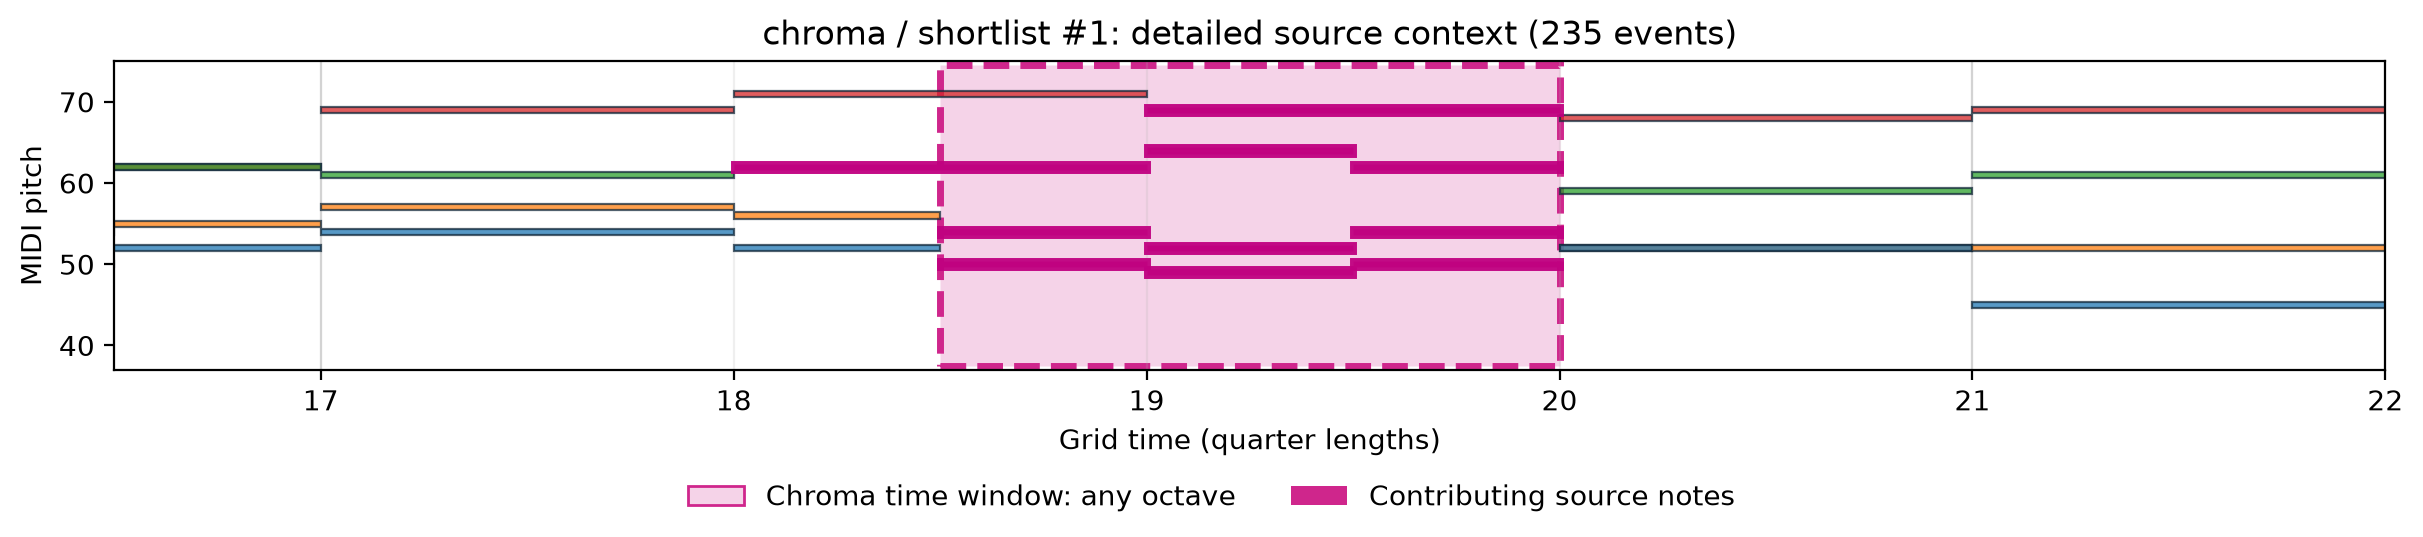

In [17]:
matched_notes = pd.DataFrame()
if trace is not None:
    matched_notes = trace["matched_notes"]
    if not matched_notes.empty:
        display(matched_notes[["xml_id", "Voice", "MIDI", "Global Onset", "Source Global Onset", "Duration"]]
                .sort_values(["Global Onset", "MIDI"]))
    plot_matched_source(selected_host, trace, context_notes=notes,
                        title=f"{SELECTED_LABEL}: detailed source context")
    plt.show()

    if INSPECT_POOL == "threshold review" and RUN_SOURCE_NOTATION and not matched_notes.empty:
        display(HTML(f"<h3>Single review candidate: {escape(SELECTED_LABEL)}</h3>"))
        with vrv_quiet():
            selected_review_svgs = vrv_render_source_context(
                matched_notes, mei_xml=mei_path.read_text(encoding="utf-8"),
                highlight_color="#cf268c", display=True,
            )


## 9. What disappears as overlap goes down?

The previous section explained **one chosen hit**. This experiment instead
compares several real source windows with **exactly the same kernel, pitch shift
and tempo**. The reference query is shown once; green cells satisfy it, red cells
are missing, and gray cells are extra source activity. More red means more loss.
The absolute start times differ, but all panels align to the beginning of their
own window. No notes are artificially deleted to produce these examples.

Choose a case/scale/shift, then select the highest-scoring window in each of four
nonoverlapping score bands: **[0.85, 1], [0.65, 0.85), [0.40, 0.65), [0, 0.40)**.
Empty bands are reported rather than filled with invented hits. These diagnostic
examples use the complete placement pool, including candidates suppressed from
the shortlist; they may overlap in time. Holding the variant fixed means the
denominator stays constant, making the increasing loss directly comparable.

Use the threshold curve to decide how many candidates to review, then use these
missing-cell patterns to decide which kinds of incompleteness you can tolerate.
Equal losses can affect different chords or pitches and need not be musically
equivalent. Extra tones are still unpenalized by this scoring rule.


chroma: D major → A major → D major; time ×0.5, shift +0 st


,score_band,score,required_cells,shared_cells,missing_cells,loss_fraction,grid_onset_QL,grid_end_QL
0,"[0.85, 1]",0.889,18,16,2,0.111,18.50,20.00
1,"[0.65, 0.85)",0.833,18,15,3,0.167,29.00,30.50
2,"[0.4, 0.65)",0.611,18,11,7,0.389,1.75,3.25
3,"[0, 0.4)",0.389,18,7,11,0.611,2.75,4.25


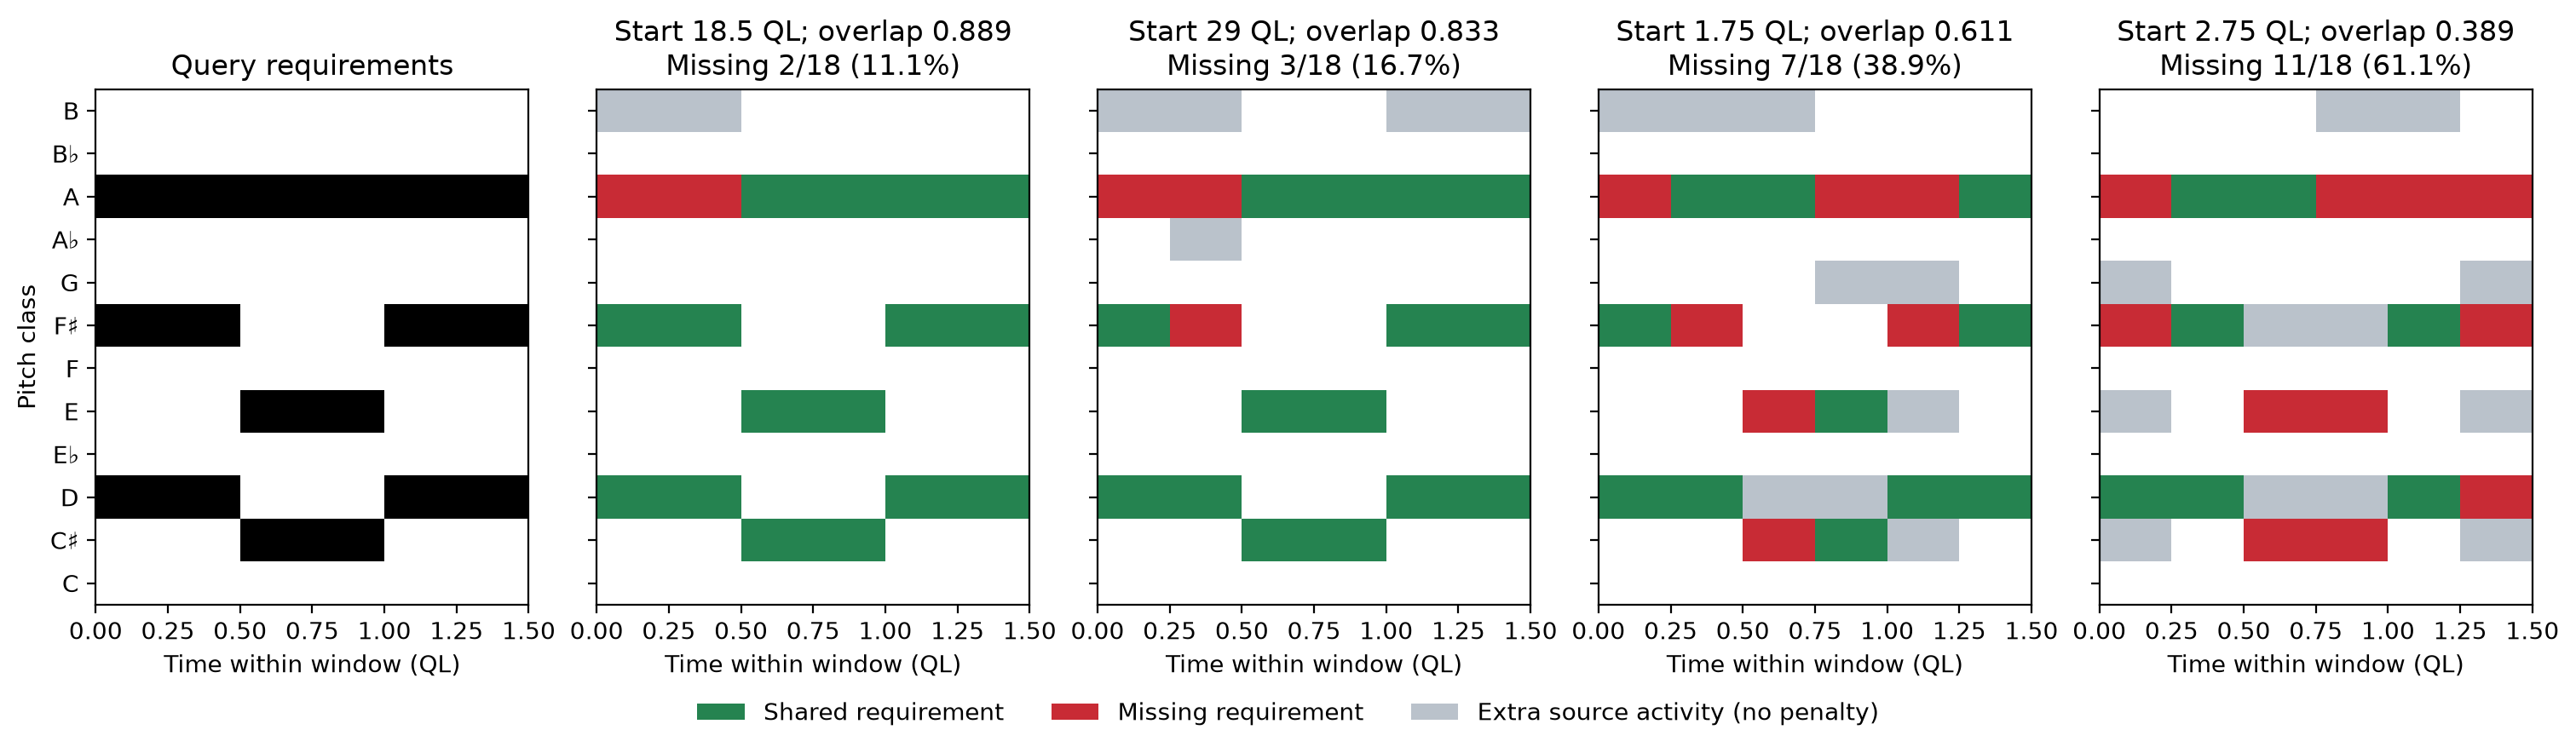

In [18]:
LOSS_CASE = "chroma"  # or MIDI fixed / MIDI moving
LOSS_TIME_SCALE = TIME_SCALES[0]
LOSS_TRANSPOSE = 0  # try -2 in MIDI moving for the C–G–C placed query
LOSS_BANDS = [(0.85, 1.0), (0.65, 0.85), (0.40, 0.65), (0.0, 0.40)]
if LOSS_CASE not in all_placements:
    raise ValueError("Choose an available search case.")
pool = all_placements[LOSS_CASE]
pool = pool[(pool["time_scale"] == LOSS_TIME_SCALE) & (pool["transpose_semitones"] == LOSS_TRANSPOSE)]
loss_rows = []
for low, high in LOSS_BANDS:
    inside = pool[(pool["score"] >= low) & ((pool["score"] <= high) if high == 1 else (pool["score"] < high))]
    if inside.empty:
        print(f"No real window in score band [{low:g}, {high:g}{']' if high == 1 else ')'}.")
        continue
    chosen = inside.sort_values("score", ascending=False, kind="stable").head(1).to_dict("records")[0]
    chosen["score_band"] = f"[{low:g}, {high:g}{']' if high == 1 else ')'}"
    loss_rows.append(chosen)
loss_examples = pd.DataFrame(loss_rows)
if not loss_examples.empty:
    print(f"{LOSS_CASE}: {placed_progression(LOSS_TRANSPOSE)}; time ×{LOSS_TIME_SCALE:g}, shift {LOSS_TRANSPOSE:+g} st")
    display(loss_examples[["score_band", "score", "required_cells", "shared_cells", "missing_cells", "loss_fraction",
                           "grid_onset_QL", "grid_end_QL"]].round(3))
    plot_query_loss_examples(case_hosts[LOSS_CASE], search_results[LOSS_CASE], loss_examples)
    plt.show()
else:
    print("No valid placements at this scale/shift; choose a variant listed in the search maps.")


The computed comparison and missing-cell report are the evidence for this
source and these settings. We have counted **all scored placements at multiple thresholds**,
separated overlap-filtered review pools from the five displayed highlights, and linked every hit to its actual source notes and
notation. A high score can still hide an incomplete chord or reflect coincident
tones distributed across voices.

Choose the next experiment according to the question:

- **Exact register/voicing matters:** start with MIDI fixed; inspect which pitches
  were absent and whether a different specified voicing is musically justified.
- **Harmony in the original pitch classes matters:** use chroma to find passages
  across octaves, then inspect bass, voices and missing tones in the source score.
- **A transposed texture or voicing matters:** use MIDI moving and read the reported
  shift and placed query labels: the −2 example requests C–G–C. The T–D–T
  relationship is a property of this transposed template; source function needs
  additional interpretation, especially for partial matches.

Refine one assumption at a time: a different voicing, omitted chord tone, tempo
range, or (as a separate experiment) all twelve chroma rotations. If chord lengths
vary independently, a uniform occupancy template may need event-based alignment.
A broader search offers more leads, not an automatic harmonic interpretation.

Reusable outputs: `queries`, all three `search_results` (including unaggregated
maps), `comparison`, `shortlist`, `hit_traces`, `hit_note_membership`,
`context_svgs`, `all_placements`, `threshold_report`, `review_matches`,
`loss_examples`, and the selected `trace` / `stage_report`. The
[methods compendium](binary_pattern_search.ipynb) provides additional recipes.
